# Simulation study



In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyvinecopulib as pv

from tabpfn.constants import ModelVersion
from npcc import PFNRBicop

In [2]:
rho = 3.0
clayton = pv.Bicop(
    family=pv.BicopFamily.clayton,
    parameters=np.asarray([[rho]], dtype=np.float64)
)
u_train = clayton.simulate(1000)

device = "cuda" if torch.cuda.is_available() else "cpu"


In [3]:
pfnr_v2_5 = PFNRBicop(
    device=device,
    model_version=ModelVersion.V2_5,
)
print("PFNRBicop device:", pfnr_v2_5._device)
pfnr_v2_5.fit(u_train[:, 0], u_train[:, 1])

PFNRBicop device: cuda


In [4]:
pfnr_v3 = PFNRBicop(
    device=device,
    model_version=ModelVersion.V3,
)
print("PFNRBicop device:", pfnr_v3._device)
pfnr_v3.fit(u_train[:, 0], u_train[:, 1])

PFNRBicop device: cuda


## Scenario 1

Simulate copula data from a Clayton copula with Kendall's $\tau$ depending on $x$ through the identity, i.e.
$$
 \tau(x) = x,
$$

for $x \in [0.01, 0.99]$.

In [3]:
def sample_scenario_1(
    n: int = 1000,
    x_min: float = 0.01,
    x_max: float = 0.99,
    seed: int = 317
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    x = np.linspace(x_min, x_max, n, dtype=np.float64)
    theta = 2.0 * x / (1.0 - x)

    eps = 1e-12
    u = rng.uniform(eps, 1.0 - eps, size=n)
    w = rng.uniform(eps, 1.0 - eps, size=n)

    # Stable inverse conditional-CDF sampler for Clayton with pair-specific theta(x).
    # Using v = u * B^(-1/theta), where B = w^(-theta/(theta+1)) - 1 + u^theta.
    log_u = np.log(u)
    log_w = np.log(w)
    log_w_term = (-theta / (theta + 1.0)) * log_w
    w_term = np.exp(log_w_term)
    u_theta = np.exp(theta * log_u)
    base = w_term - 1.0 + u_theta
    base = np.maximum(base, eps)
    log_v = log_u - np.log(base) / theta
    v = np.exp(log_v)

    return pd.DataFrame({"u": u, "v": v, "x": x})

In [6]:
df = sample_scenario_1(n=500)
df.head()

,u,v,x
0,0.934290,0.045436,0.010000
1,0.207307,0.530704,0.011964
2,0.984312,0.769884,0.013928
3,0.808883,0.737380,0.015892
4,0.147902,0.246998,0.017856


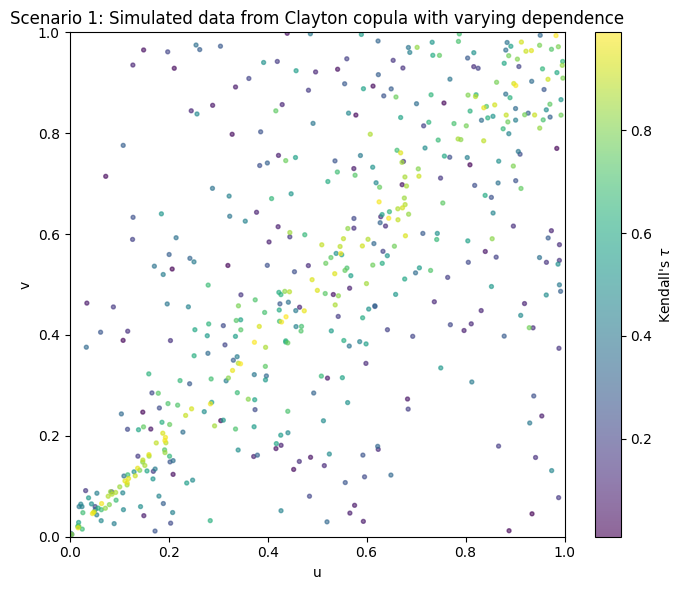

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(df["u"], df["v"], c=df["x"], s=8, alpha=0.6, cmap="viridis")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Kendall's $\\tau$")
ax.set_title("Scenario 1: Simulated data from Clayton copula with varying dependence")
ax.set_xlabel("u")
ax.set_ylabel("v")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
pfnr_v2_5_sc_1 = PFNRBicop(
    device=device,
    model_version=ModelVersion.V2_5,
)
pfnr_v2_5_sc_1.fit(df["u"].values, df["v"].values, df["x"].values)

df["c_hat"] = pfnr_v2_5_sc_1.pdf(df["u"].values, df["v"].values, x = df["x"].values)
df.head()

In [ ]:
pfnr_v3_sc_1 = PFNRBicop(
    device=device,
    model_version=ModelVersion.V3,
)
pfnr_v3_sc_1.fit(df["u"].values, df["v"].values, df["x"].values)

df["c_hat"] = pfnr_v3_sc_1.pdf(df["u"].values, df["v"].values, x = df["x"].values)
df.head()

In [4]:
x_eval = np.linspace(0.01, 0.99, 50)

uv_pairs = [
    (0.1, 0.1), (0.1, 0.3), (0.1, 0.5), (0.1, 0.7), (0.1, 0.9),
    (0.3, 0.1), (0.3, 0.3), (0.3, 0.5), (0.3, 0.7), (0.3, 0.9),
    (0.5, 0.1), (0.5, 0.3), (0.5, 0.5), (0.5, 0.7), (0.5, 0.9),
    (0.7, 0.1), (0.7, 0.3), (0.7, 0.5), (0.7, 0.7), (0.7, 0.9),
    (0.9, 0.1), (0.9, 0.3), (0.9, 0.5), (0.9, 0.7), (0.9, 0.9)
]

def clayton_theta(x_vals: np.ndarray) -> np.ndarray:
    return 2.0 * x_vals / (1.0 - x_vals)

theta_eval = clayton_theta(x_eval)

def clayton_pdf_true(u_val: float, v_val: float, theta: np.ndarray) -> np.ndarray:
    log_u = np.log(u_val)
    log_v = np.log(v_val)

    log_u_neg_theta = -theta * log_u
    log_v_neg_theta = -theta * log_v
    max_log_term = np.maximum(log_u_neg_theta, log_v_neg_theta)
    sum_core = (
        np.exp(log_u_neg_theta - max_log_term)
        + np.exp(log_v_neg_theta - max_log_term)
        - np.exp(-max_log_term)
    )

    log_sum_term = max_log_term + np.log(sum_core)
    log_pdf_true = (
        np.log(theta + 1.0)
        + (-theta - 1.0) * (log_u + log_v)
        + (-2.0 - 1.0 / theta) * log_sum_term
    )
    return np.exp(log_pdf_true)

def clayton_cdf_true(u_val: float, v_val: float, theta: np.ndarray) -> np.ndarray:
    log_u = np.log(u_val)
    log_v = np.log(v_val)

    log_u_neg_theta = -theta * log_u
    log_v_neg_theta = -theta * log_v
    max_log_term = np.maximum(log_u_neg_theta, log_v_neg_theta)
    sum_core = (
        np.exp(log_u_neg_theta - max_log_term)
        + np.exp(log_v_neg_theta - max_log_term)
        - np.exp(-max_log_term)
    )

    log_sum_term = max_log_term + np.log(sum_core)
    log_cdf_true = (-1.0 / theta) * log_sum_term
    return np.exp(log_cdf_true)

def clayton_hfunc1_true(u_val: float, v_val: float, theta: np.ndarray) -> np.ndarray:
    log_u = np.log(u_val)
    log_v = np.log(v_val)

    log_u_neg_theta = -theta * log_u
    log_v_neg_theta = -theta * log_v
    max_log_term = np.maximum(log_u_neg_theta, log_v_neg_theta)
    sum_core = (
        np.exp(log_u_neg_theta - max_log_term)
        + np.exp(log_v_neg_theta - max_log_term)
        - np.exp(-max_log_term)
    )

    log_sum_term = max_log_term + np.log(sum_core)
    log_hfunc1_true = (-theta - 1.0) * log_u + (-1.0 / theta - 1.0) * log_sum_term
    return np.exp(log_hfunc1_true)

def clayton_hfunc2_true(u_val: float, v_val: float, theta: np.ndarray) -> np.ndarray:
    log_u = np.log(u_val)
    log_v = np.log(v_val)

    log_u_neg_theta = -theta * log_u
    log_v_neg_theta = -theta * log_v
    max_log_term = np.maximum(log_u_neg_theta, log_v_neg_theta)
    sum_core = (
        np.exp(log_u_neg_theta - max_log_term)
        + np.exp(log_v_neg_theta - max_log_term)
        - np.exp(-max_log_term)
    )

    log_sum_term = max_log_term + np.log(sum_core)
    log_hfunc2_true = (-theta - 1.0) * log_v + (-1.0 / theta - 1.0) * log_sum_term
    return np.exp(log_hfunc2_true)


def precompute_true_curves(uv_pairs: list[tuple[float, float]], theta: np.ndarray) -> dict:
    true_curves = {}
    for u_val, v_val in uv_pairs:
        true_curves[(u_val, v_val)] = {
            "pdf": clayton_pdf_true(u_val, v_val, theta),
            "cdf": clayton_cdf_true(u_val, v_val, theta),
            "hfunc1": clayton_hfunc1_true(u_val, v_val, theta),
            "hfunc2": clayton_hfunc2_true(u_val, v_val, theta),
        }
    return true_curves


TRUE_CURVES = precompute_true_curves(uv_pairs, theta_eval)

# One-time batched evaluation grids reused across all repetitions.
N_PAIRS = len(uv_pairs)
N_X = len(x_eval)

U_PAIR = np.asarray([u for u, _ in uv_pairs], dtype=np.float64)
V_PAIR = np.asarray([v for _, v in uv_pairs], dtype=np.float64)

U_EVAL_GRID = np.repeat(U_PAIR[:, None], N_X, axis=1)
V_EVAL_GRID = np.repeat(V_PAIR[:, None], N_X, axis=1)
X_EVAL_GRID = np.repeat(x_eval[None, :], N_PAIRS, axis=0)

U_EVAL_FLAT = U_EVAL_GRID.reshape(-1)
V_EVAL_FLAT = V_EVAL_GRID.reshape(-1)
X_EVAL_FLAT = X_EVAL_GRID.reshape(-1)

TRUE_PDF_GRID = np.stack([TRUE_CURVES[(u, v)]["pdf"] for u, v in uv_pairs], axis=0)
TRUE_CDF_GRID = np.stack([TRUE_CURVES[(u, v)]["cdf"] for u, v in uv_pairs], axis=0)
TRUE_HFUNC1_GRID = np.stack([TRUE_CURVES[(u, v)]["hfunc1"] for u, v in uv_pairs], axis=0)
TRUE_HFUNC2_GRID = np.stack([TRUE_CURVES[(u, v)]["hfunc2"] for u, v in uv_pairs], axis=0)

In [ ]:
fig, axes = plt.subplots(5, 5, figsize=(20, 20))
for (u_val, v_val), ax in zip(uv_pairs, axes.flatten()):
    pdf_hat_vals_v2_5 = pfnr_v2_5_sc_1.pdf(
        np.full_like(x_eval, u_val),
        np.full_like(x_eval, v_val),
        x=x_eval
    )
    pdf_hat_vals_v3 = pfnr_v3_sc_1.pdf(
        np.full_like(x_eval, u_val),
        np.full_like(x_eval, v_val),
        x=x_eval
    )
    pdf_true = clayton_pdf_true(u_val, v_val, theta_eval)

    ax.plot(x_eval, pdf_hat_vals_v2_5, label="V2.5")
    ax.plot(x_eval, pdf_hat_vals_v3, label="V3")
    ax.plot(x_eval, pdf_true, label="True", linestyle="dashed")
    ax.set_title(f"u={u_val}, v={v_val}")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.suptitle(
    "Fitted vs True Conditional Copula PDF Across 25 (u, v) Pairs",
    fontsize=24,
    fontweight="bold",
    y=0.995
)
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.968),
    ncol=3,
    frameon=False,
    fontsize=12
)
fig.supxlabel("$\\tau(x)$", fontsize=20)
fig.supylabel("$\\hat{c}(u,v|x)$", fontsize=20)

plt.tight_layout(rect=[0.02, 0.02, 1, 0.93])
plt.show()

In [ ]:
ratio_ylim = (0.0, 2.0)

ratio_curves = []
for u_val, v_val in uv_pairs:
    pdf_hat_vals_v2_5 = pfnr_v2_5_sc_1.pdf(
        np.full_like(x_eval, u_val),
        np.full_like(x_eval, v_val),
        x=x_eval
    )

    pdf_hat_vals_v3 = pfnr_v3_sc_1.pdf(
        np.full_like(x_eval, u_val),
        np.full_like(x_eval, v_val),
        x=x_eval
    )

    pdf_true = clayton_pdf_true(u_val, v_val, theta_eval)

    valid = (pdf_true > 0) & np.isfinite(pdf_true)

    ratio_vals_v2_5 = np.divide(
        pdf_hat_vals_v2_5,
        pdf_true,
        out=np.full_like(pdf_hat_vals_v2_5, np.nan, dtype=np.float64),
        where=valid
    )

    ratio_vals_v3 = np.divide(
        pdf_hat_vals_v3,
        pdf_true,
        out=np.full_like(pdf_hat_vals_v3, np.nan, dtype=np.float64),
        where=valid
    )

    ratio_curves.append(((u_val, v_val), ratio_vals_v2_5, ratio_vals_v3))


fig, axes = plt.subplots(5, 5, figsize=(20, 20))

for ((u_val, v_val), ratio_vals_v2_5, ratio_vals_v3), ax in zip(
    ratio_curves,
    axes.flatten()
):
    ax.plot(x_eval, ratio_vals_v2_5, label="V2.5 / True")
    ax.plot(x_eval, ratio_vals_v3, label="V3 / True")
    ax.axhline(1.0, color="black", linestyle="dashed", linewidth=1)

    ax.set_title(f"u={u_val}, v={v_val}")
    ax.set_xlim(x_eval.min(), x_eval.max())
    ax.set_ylim(*ratio_ylim)


handles, labels = axes[0, 0].get_legend_handles_labels()

fig.suptitle(
    "Estimated-to-True PDF Ratio Across 25 (u, v) Pairs",
    fontsize=24,
    fontweight="bold",
    y=0.995
)

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.968),
    ncol=3,
    frameon=False,
    fontsize=12
)

fig.supxlabel("$\\tau(x)$", fontsize=20)
fig.supylabel("Estimated PDF / True PDF", fontsize=20)

plt.tight_layout(rect=[0.02, 0.02, 1, 0.93])
plt.show()

In [ ]:
fig, axes = plt.subplots(5, 5, figsize=(20, 20))
for (u_val, v_val), ax in zip(uv_pairs, axes.flatten()):
    cdf_hat_vals_v2_5 = pfnr_v2_5_sc_1.cdf(
        np.full_like(x_eval, u_val),
        np.full_like(x_eval, v_val),
        x=x_eval
    )

    cdf_hat_vals_v3 = pfnr_v3_sc_1.cdf(
        np.full_like(x_eval, u_val),
        np.full_like(x_eval, v_val),
        x=x_eval
    )

    theta = 2.0 * x_eval / (1.0 - x_eval)
    cdf_true = (u_val ** (-theta) + v_val ** (-theta) - 1.0) ** (-1.0 / theta)

    ax.plot(x_eval, cdf_hat_vals_v2_5, label="V2.5")
    ax.plot(x_eval, cdf_hat_vals_v3, label="V3")
    ax.plot(x_eval, cdf_true, label="True", linestyle="dashed")
    ax.set_title(f"u={u_val}, v={v_val}")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.suptitle(
    "Fitted vs True Conditional Copula CDF Across 25 (u, v) Pairs",
    fontsize=24,
    fontweight="bold",
    y=0.995
)
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.968),
    ncol=3,
    frameon=False,
    fontsize=12
)
fig.supxlabel("$\\tau(x)$", fontsize=20)
fig.supylabel("$\\hat{C}(u,v|x)$", fontsize=20)

plt.tight_layout(rect=[0.02, 0.02, 1, 0.93])
plt.show()

In [ ]:
cdf_ratio_ylim = (0.0, 2.0)

cdf_ratio_curves = []
for u_val, v_val in uv_pairs:
    cdf_hat_vals_v2_5 = pfnr_v2_5_sc_1.cdf(
        np.full_like(x_eval, u_val),
        np.full_like(x_eval, v_val),
        x=x_eval
    )

    cdf_hat_vals_v3 = pfnr_v3_sc_1.cdf(
        np.full_like(x_eval, u_val),
        np.full_like(x_eval, v_val),
        x=x_eval
    )

    cdf_true = clayton_cdf_true(u_val, v_val, theta_eval)

    valid = (cdf_true > 0) & np.isfinite(cdf_true)

    cdf_ratio_vals_v2_5 = np.divide(
        cdf_hat_vals_v2_5,
        cdf_true,
        out=np.full_like(cdf_hat_vals_v2_5, np.nan, dtype=np.float64),
        where=valid
    )

    cdf_ratio_vals_v3 = np.divide(
        cdf_hat_vals_v3,
        cdf_true,
        out=np.full_like(cdf_hat_vals_v3, np.nan, dtype=np.float64),
        where=valid
    )

    cdf_ratio_curves.append(((u_val, v_val), cdf_ratio_vals_v2_5, cdf_ratio_vals_v3))


fig, axes = plt.subplots(5, 5, figsize=(20, 20))

for ((u_val, v_val), cdf_ratio_vals_v2_5, cdf_ratio_vals_v3), ax in zip(
    cdf_ratio_curves,
    axes.flatten()
):
    ax.plot(x_eval, cdf_ratio_vals_v2_5, label="V2.5 / True")
    ax.plot(x_eval, cdf_ratio_vals_v3, label="V3 / True")
    ax.axhline(1.0, color="black", linestyle="dashed", linewidth=1)

    ax.set_title(f"u={u_val}, v={v_val}")
    ax.set_xlim(x_eval.min(), x_eval.max())
    ax.set_ylim(*cdf_ratio_ylim)


handles, labels = axes[0, 0].get_legend_handles_labels()

fig.suptitle(
    "Estimated-to-True CDF Ratio Across 25 (u, v) Pairs",
    fontsize=24,
    fontweight="bold",
    y=0.995
)

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.968),
    ncol=3,
    frameon=False,
    fontsize=12
)

fig.supxlabel("$\\tau(x)$", fontsize=20)
fig.supylabel("Estimated CDF / True CDF", fontsize=20)

plt.tight_layout(rect=[0.02, 0.02, 1, 0.93])
plt.show()

In [ ]:
fig, axes = plt.subplots(5, 5, figsize=(20, 20))
for (u_val, v_val), ax in zip(uv_pairs, axes.flatten()):
    hfunc1_hat_vals_v2_5 = pfnr_v2_5_sc_1.hfunc1(
        np.full_like(x_eval, u_val),
        np.full_like(x_eval, v_val),
        x=x_eval
    )

    hfunc1_hat_vals_v3 = pfnr_v3_sc_1.hfunc1(
        np.full_like(x_eval, u_val),
        np.full_like(x_eval, v_val),
        x=x_eval
    )

    hfunc1_true = clayton_hfunc1_true(u_val, v_val, theta_eval)

    ax.plot(x_eval, hfunc1_hat_vals_v2_5, label="V2.5")
    ax.plot(x_eval, hfunc1_hat_vals_v3, label="V3")
    ax.plot(x_eval, hfunc1_true, label="True", linestyle="dashed")
    ax.set_title(f"u={u_val}, v={v_val}")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.suptitle(
    "Fitted vs True Conditional Copula hfunc1 Across 25 (u, v) Pairs",
    fontsize=24,
    fontweight="bold",
    y=0.995
)
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.968),
    ncol=3,
    frameon=False,
    fontsize=12
)
fig.supxlabel("$\\tau(x)$", fontsize=20)
fig.supylabel("$\\hat{h}_{v|u,x}(v|u,x)$", fontsize=20)

plt.tight_layout(rect=[0.02, 0.02, 1, 0.93])
plt.show()

In [ ]:
hfunc1_ratio_ylim = (0.0, 2.0)

hfunc1_ratio_curves = []
for u_val, v_val in uv_pairs:
    hfunc1_hat_vals_v2_5 = pfnr_v2_5_sc_1.hfunc1(
        np.full_like(x_eval, u_val),
        np.full_like(x_eval, v_val),
        x=x_eval
    )

    hfunc1_hat_vals_v3 = pfnr_v3_sc_1.hfunc1(
        np.full_like(x_eval, u_val),
        np.full_like(x_eval, v_val),
        x=x_eval
    )

    hfunc1_true = clayton_hfunc1_true(u_val, v_val, theta_eval)

    valid = (hfunc1_true > 0) & np.isfinite(hfunc1_true)

    hfunc1_ratio_vals_v2_5 = np.divide(
        hfunc1_hat_vals_v2_5,
        hfunc1_true,
        out=np.full_like(hfunc1_hat_vals_v2_5, np.nan, dtype=np.float64),
        where=valid
    )

    hfunc1_ratio_vals_v3 = np.divide(
        hfunc1_hat_vals_v3,
        hfunc1_true,
        out=np.full_like(hfunc1_hat_vals_v3, np.nan, dtype=np.float64),
        where=valid
    )

    hfunc1_ratio_curves.append(
        ((u_val, v_val), hfunc1_ratio_vals_v2_5, hfunc1_ratio_vals_v3)
    )


fig, axes = plt.subplots(5, 5, figsize=(20, 20))

for ((u_val, v_val), ratio_v2_5, ratio_v3), ax in zip(
    hfunc1_ratio_curves,
    axes.flatten()
):
    ax.plot(x_eval, ratio_v2_5, label="V2.5 / True")
    ax.plot(x_eval, ratio_v3, label="V3 / True")
    ax.axhline(1.0, color="black", linestyle="dashed", linewidth=1)

    ax.set_title(f"u={u_val}, v={v_val}")
    ax.set_xlim(x_eval.min(), x_eval.max())
    ax.set_ylim(*hfunc1_ratio_ylim)


handles, labels = axes[0, 0].get_legend_handles_labels()

fig.suptitle(
    "Estimated-to-True hfunc1 Ratio Across 25 (u, v) Pairs",
    fontsize=24,
    fontweight="bold",
    y=0.995
)

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.968),
    ncol=3,
    frameon=False,
    fontsize=12
)

fig.supxlabel("$\\tau(x)$", fontsize=20)
fig.supylabel("Estimated hfunc1 / True hfunc1", fontsize=20)

plt.tight_layout(rect=[0.02, 0.02, 1, 0.93])
plt.show()

In [ ]:
fig, axes = plt.subplots(5, 5, figsize=(20, 20))
for (u_val, v_val), ax in zip(uv_pairs, axes.flatten()):
    hfunc2_hat_vals_v2_5 = pfnr_v2_5_sc_1.hfunc2(
        np.full_like(x_eval, u_val),
        np.full_like(x_eval, v_val),
        x=x_eval
    )

    hfunc2_hat_vals_v3 = pfnr_v3_sc_1.hfunc2(
        np.full_like(x_eval, u_val),
        np.full_like(x_eval, v_val),
        x=x_eval
    )

    hfunc2_true = clayton_hfunc2_true(u_val, v_val, theta_eval)

    ax.plot(x_eval, hfunc2_hat_vals_v2_5, label="V2.5")
    ax.plot(x_eval, hfunc2_hat_vals_v3, label="V3")
    ax.plot(x_eval, hfunc2_true, label="True", linestyle="dashed")
    ax.set_title(f"u={u_val}, v={v_val}")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.suptitle(
    "Fitted vs True Conditional Copula hfunc2 Across 25 (u, v) Pairs",
    fontsize=24,
    fontweight="bold",
    y=0.995
)
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.968),
    ncol=3,
    frameon=False,
    fontsize=12
)
fig.supxlabel("$\\tau(x)$", fontsize=20)
fig.supylabel("$\\hat{h}_{v|u,x}(v|u,x)$", fontsize=20)

plt.tight_layout(rect=[0.02, 0.02, 1, 0.93])
plt.show()

In [ ]:
hfunc2_ratio_ylim = (0.0, 2.0)

hfunc2_ratio_curves = []
for u_val, v_val in uv_pairs:
    hfunc2_hat_vals_v2_5 = pfnr_v2_5_sc_1.hfunc2(
        np.full_like(x_eval, u_val),
        np.full_like(x_eval, v_val),
        x=x_eval
    )

    hfunc2_hat_vals_v3 = pfnr_v3_sc_1.hfunc2(
        np.full_like(x_eval, u_val),
        np.full_like(x_eval, v_val),
        x=x_eval
    )

    hfunc2_true = clayton_hfunc2_true(u_val, v_val, theta_eval)

    valid = (hfunc2_true > 0) & np.isfinite(hfunc2_true)

    hfunc2_ratio_vals_v2_5 = np.divide(
        hfunc2_hat_vals_v2_5,
        hfunc2_true,
        out=np.full_like(hfunc2_hat_vals_v2_5, np.nan, dtype=np.float64),
        where=valid
    )

    hfunc2_ratio_vals_v3 = np.divide(
        hfunc2_hat_vals_v3,
        hfunc2_true,
        out=np.full_like(hfunc2_hat_vals_v3, np.nan, dtype=np.float64),
        where=valid
    )

    hfunc2_ratio_curves.append(
        ((u_val, v_val), hfunc2_ratio_vals_v2_5, hfunc2_ratio_vals_v3)
    )


fig, axes = plt.subplots(5, 5, figsize=(20, 20))

for ((u_val, v_val), ratio_v2_5, ratio_v3), ax in zip(
    hfunc2_ratio_curves,
    axes.flatten()
):
    ax.plot(x_eval, ratio_v2_5, label="V2.5 / True")
    ax.plot(x_eval, ratio_v3, label="V3 / True")
    ax.axhline(1.0, color="black", linestyle="dashed", linewidth=1)

    ax.set_title(f"u={u_val}, v={v_val}")
    ax.set_xlim(x_eval.min(), x_eval.max())
    ax.set_ylim(*hfunc2_ratio_ylim)


handles, labels = axes[0, 0].get_legend_handles_labels()

fig.suptitle(
    "Estimated-to-True hfunc2 Ratio Across 25 (u, v) Pairs",
    fontsize=24,
    fontweight="bold",
    y=0.995
)

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.968),
    ncol=3,
    frameon=False,
    fontsize=12
)

fig.supxlabel("$\\tau(x)$", fontsize=20)
fig.supylabel("Estimated hfunc2 / True hfunc2", fontsize=20)

plt.tight_layout(rect=[0.02, 0.02, 1, 0.93])
plt.show()

## Error metrics used for model-vs-truth comparison

For each fixed pair $(u,v)$, we compare the estimated curve $\hat{f}(x)$ to the true curve $f(x)$ over the grid `x_eval`.

Let $e(x)=\hat{f}(x)-f(x)$.

- **MAE (mean absolute error)**: $\frac{1}{m}\sum_{j=1}^m |e(x_j)|$
- **RMSE (root mean squared error)**: $\sqrt{\frac{1}{m}\sum_{j=1}^m e(x_j)^2}$
- **MaxAE (maximum absolute error)**: $\max_j |e(x_j)|$
- **IAE (integrated absolute error)**: $\int |e(x)|\,dx$ (numerically via trapezoid rule)
- **ISE (integrated squared error)**: $\int e(x)^2\,dx$ (numerically via trapezoid rule)
- **MRAE (mean relative absolute error)**: $\frac{1}{m}\sum_{j=1}^m \frac{|e(x_j)|}{|f(x_j)|+\varepsilon}$
- **KL distance (PDF only, normalized over x)**:
  First normalize over `x_eval`: $p(x)=\frac{f(x)}{\int f},\; q(x)=\frac{\hat f(x)}{\int \hat f}$, then
  $$
  D_{KL}(p\,\|\,q)=\int p(x)\log\frac{p(x)}{q(x)}\,dx
  $$

We report metrics per $(u,v)$ pair, then aggregate across all pairs with mean, median, 95th percentile, and max.

## Multi-repetition study across sample sizes

The previous metrics chunk is kept as the **single-repetition showcase**.

This section repeats the simulation for multiple sample sizes and repetitions, then aggregates performance across repetitions.

Default start values:

- `N_REP = 20`
- `N_LIST = [200, 500, 1000]`

Outputs from this section:

- `rep_results_long`: per-repetition summary metrics (already aggregated over `(u, v)` pairs within each repetition)
- `mc_summary`: aggregated performance over repetitions
- `runtime_summary`: runtime aggregation over repetitions

In [22]:
from Simulation_Study_helpers import run_repetitions, aggregate_results, curve_metrics, plot_metric_uv_boxgrid, plot_all_uv_metric_boxgrids, plot_all_avg_uv_metric_boxplots

ImportError: cannot import name 'plot_all_avg_uv_metric_boxplots' from 'Simulation_Study_helpers' (c:\Users\flbuc\OneDrive\Documents\Research\npcc\notebooks\Simulation_Study_helpers.py)

In [6]:
rep_results, runtime, wall = run_repetitions(
    n_list=[200, 500, 1000],
    n_rep=2,
    base_seed=42,
    num_workers=1,

    device=device,
    sample_scenario_1=sample_scenario_1,
    curve_metrics=curve_metrics,
    PFNRBicop=PFNRBicop,

    U_EVAL_FLAT=U_EVAL_FLAT,
    V_EVAL_FLAT=V_EVAL_FLAT,
    X_EVAL_FLAT=X_EVAL_FLAT,

    TRUE_PDF_GRID=TRUE_PDF_GRID,
    TRUE_CDF_GRID=TRUE_CDF_GRID,
    TRUE_HFUNC1_GRID=TRUE_HFUNC1_GRID,
    TRUE_HFUNC2_GRID=TRUE_HFUNC2_GRID,

    uv_pairs=uv_pairs,
    x_eval=x_eval,
    N_PAIRS=N_PAIRS,
    N_X=N_X,
)

C:\Users\flbuc\OneDrive\Documents\Research\npcc\src\npcc\_common.py:49: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  return torch.as_tensor(np.asarray(x), dtype=dtype, device=device)


In [7]:
mc_summary_long, mc_summary_wide, runtime_summary_long, runtime_summary_wide = (
    aggregate_results(rep_results, runtime)
)

c:\Users\flbuc\OneDrive\Documents\Research\npcc\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1573: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


In [8]:
display(runtime_summary_long)

,model,n,fit_time_mean,fit_time_std,fit_time_p95,pdf_time_mean,pdf_time_std,pdf_time_p95,cdf_time_mean,cdf_time_std,cdf_time_p95,h1_time_mean,h1_time_std,h1_time_p95,h2_time_mean,h2_time_std,h2_time_p95,total_model_time_mean,total_model_time_std,total_model_time_p95
0,V2.5,200,1.484819,1.584131,2.492954,0.930148,0.242750,1.084633,7.777806,0.205153,7.908364,0.421563,0.059388,0.459357,0.444664,0.007309,0.449316,11.062743,1.569648,12.061661
1,V2.5,500,0.450331,0.065116,0.491771,0.853241,0.046018,0.882527,9.516354,1.718116,10.609756,0.379332,0.014648,0.388654,0.385868,0.025357,0.402005,11.588789,1.646946,12.636900
2,V2.5,1000,0.429075,0.004316,0.431822,0.926848,0.221040,1.067518,8.699483,0.038676,8.724096,0.449608,0.057885,0.486446,0.434545,0.048305,0.465286,10.943531,0.149194,11.038478
3,V3,200,1.641717,0.004532,1.644601,1.779871,0.437459,2.058268,13.408049,0.149355,13.503098,0.592231,0.025807,0.608655,0.594552,0.007888,0.599572,18.020131,0.609262,18.407863
4,V3,500,1.484032,0.064566,1.525122,1.207844,0.022642,1.222254,14.032839,0.251420,14.192842,0.609484,0.036749,0.632871,0.583348,0.000718,0.583805,17.922299,0.373313,18.159874
5,V3,1000,1.489489,0.007533,1.494283,1.479278,0.001137,1.480002,14.241052,0.212707,14.376419,0.801009,0.153454,0.898666,0.763935,0.122747,0.842051,18.778695,0.057502,18.815289


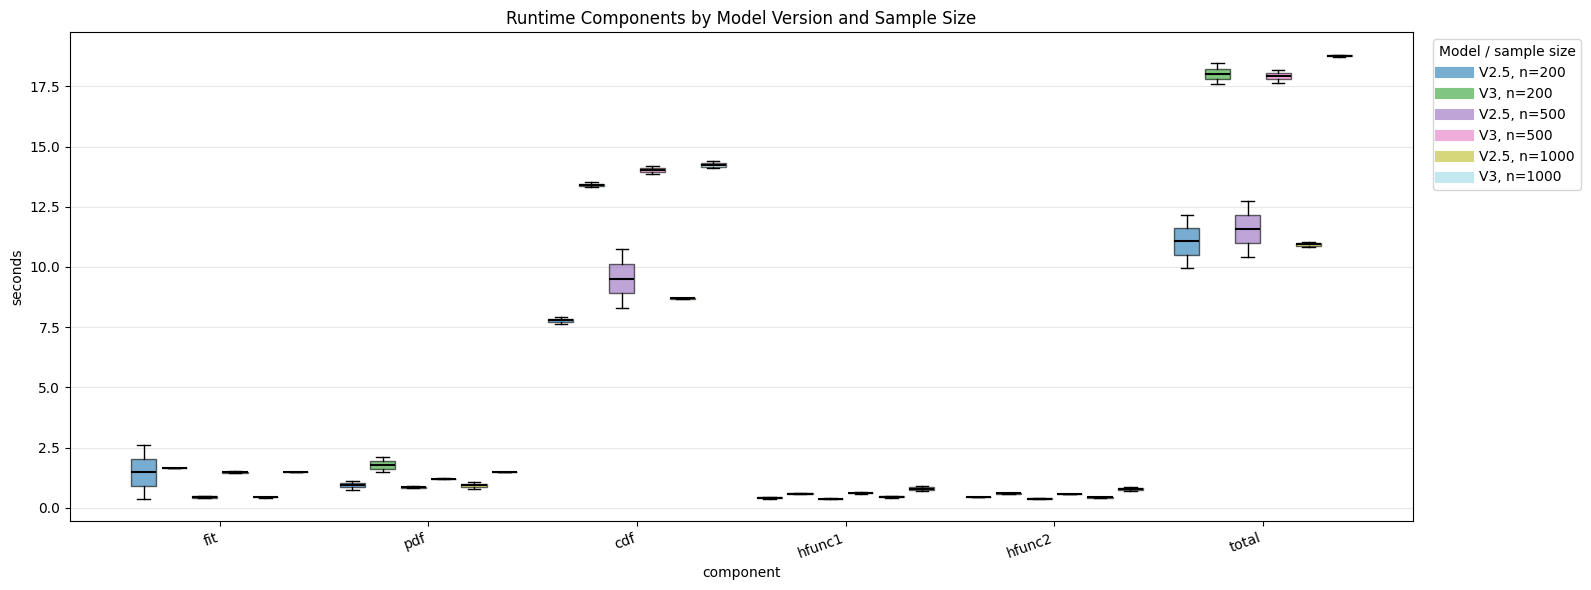

In [9]:
# Grouped boxplot: components on x-axis, model + n indicated by color

if runtime.empty:
    print("No runtime data. Run the Monte Carlo experiment cell first.")
else:
    component_cols = [
        "fit_time",
        "pdf_time",
        "cdf_time",
        "h1_time",
        "h2_time",
        "total_model_time",
    ]

    # Optional: include total_rep_time only once per replicate, but it is shared across models,
    # so it can be misleading in a per-model comparison.
    # If you really want it, uncomment:
    # component_cols.append("total_rep_time")

    available_cols = [c for c in component_cols if c in runtime.columns]

    if not available_cols:
        print("No component timing columns found in runtime_long.")
    else:
        n_vals = sorted(runtime["n"].unique())
        model_vals = list(runtime["model"].dropna().unique())

        groups = [
            (model_name, n)
            for n in n_vals
            for model_name in model_vals
        ]

        group_count = len(groups)

        fig, ax = plt.subplots(figsize=(16, 6))

        base_positions = np.arange(len(available_cols), dtype=float)
        group_width = 0.85
        box_width = (group_width / max(group_count, 1)) * 0.85

        if group_count == 1:
            offsets = np.array([0.0])
        else:
            offsets = np.linspace(
                -group_width / 2 + box_width / 2,
                group_width / 2 - box_width / 2,
                group_count,
            )

        colors = plt.cm.tab20(np.linspace(0, 1, max(group_count, 1)))

        for i, (model_name, n) in enumerate(groups):
            mask = (
                (runtime["model"] == model_name)
                & (runtime["n"] == n)
            )

            grouped = [
                runtime.loc[mask, col].dropna().values
                for col in available_cols
            ]

            # Skip empty groups
            if all(len(vals) == 0 for vals in grouped):
                continue

            positions = base_positions + offsets[i]

            box = ax.boxplot(
                grouped,
                positions=positions,
                widths=box_width,
                patch_artist=True,
                showfliers=True,
                manage_ticks=False,
            )

            for patch in box["boxes"]:
                patch.set_facecolor(colors[i])
                patch.set_alpha(0.6)

            for median in box["medians"]:
                median.set_color("black")
                median.set_linewidth(1.5)

        pretty_labels = [
            c.replace("_time", "")
             .replace("total_model", "total")
             .replace("h1", "hfunc1")
             .replace("h2", "hfunc2")
             .replace("_", " ")
            for c in available_cols
        ]

        ax.set_xticks(base_positions)
        ax.set_xticklabels(pretty_labels, rotation=20, ha="right")

        ax.set_ylabel("seconds")
        ax.set_xlabel("component")
        ax.set_title("Runtime Components by Model Version and Sample Size")
        ax.grid(axis="y", alpha=0.3)

        legend_handles = [
            plt.Line2D(
                [0],
                [0],
                color=colors[i],
                lw=8,
                alpha=0.6,
                label=f"{model_name}, n={n}",
            )
            for i, (model_name, n) in enumerate(groups)
        ]

        ax.legend(
            handles=legend_handles,
            title="Model / sample size",
            loc="upper left",
            bbox_to_anchor=(1.01, 1.0),
        )

        fig.tight_layout()
        plt.show()


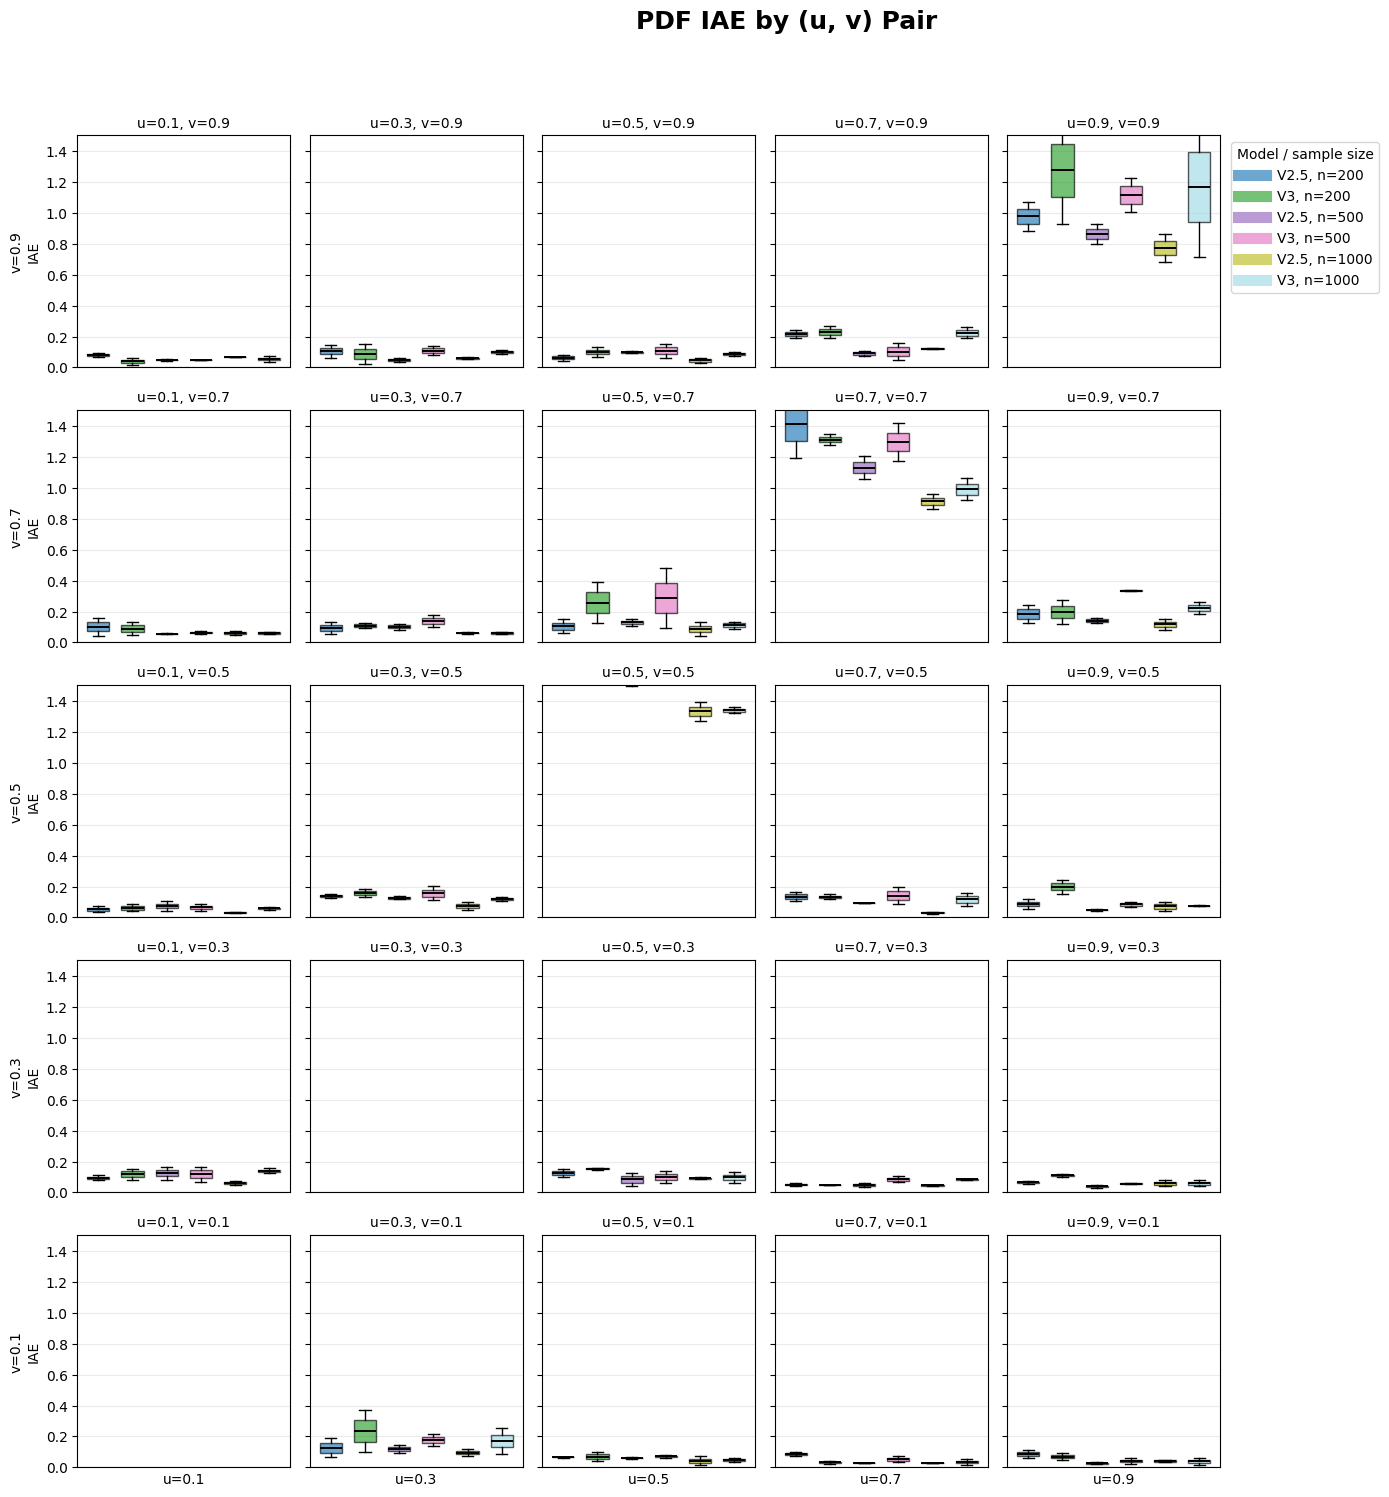

In [12]:
plot_metric_uv_boxgrid(
    rep_results,
    quantity="pdf",
    metric="IAE",
    uv_pairs=uv_pairs,
    model_order=["V2.5", "V3"],
    ylim=(0.0, 1.5),
    title="PDF IAE by (u, v) Pair",
)
plt.show()

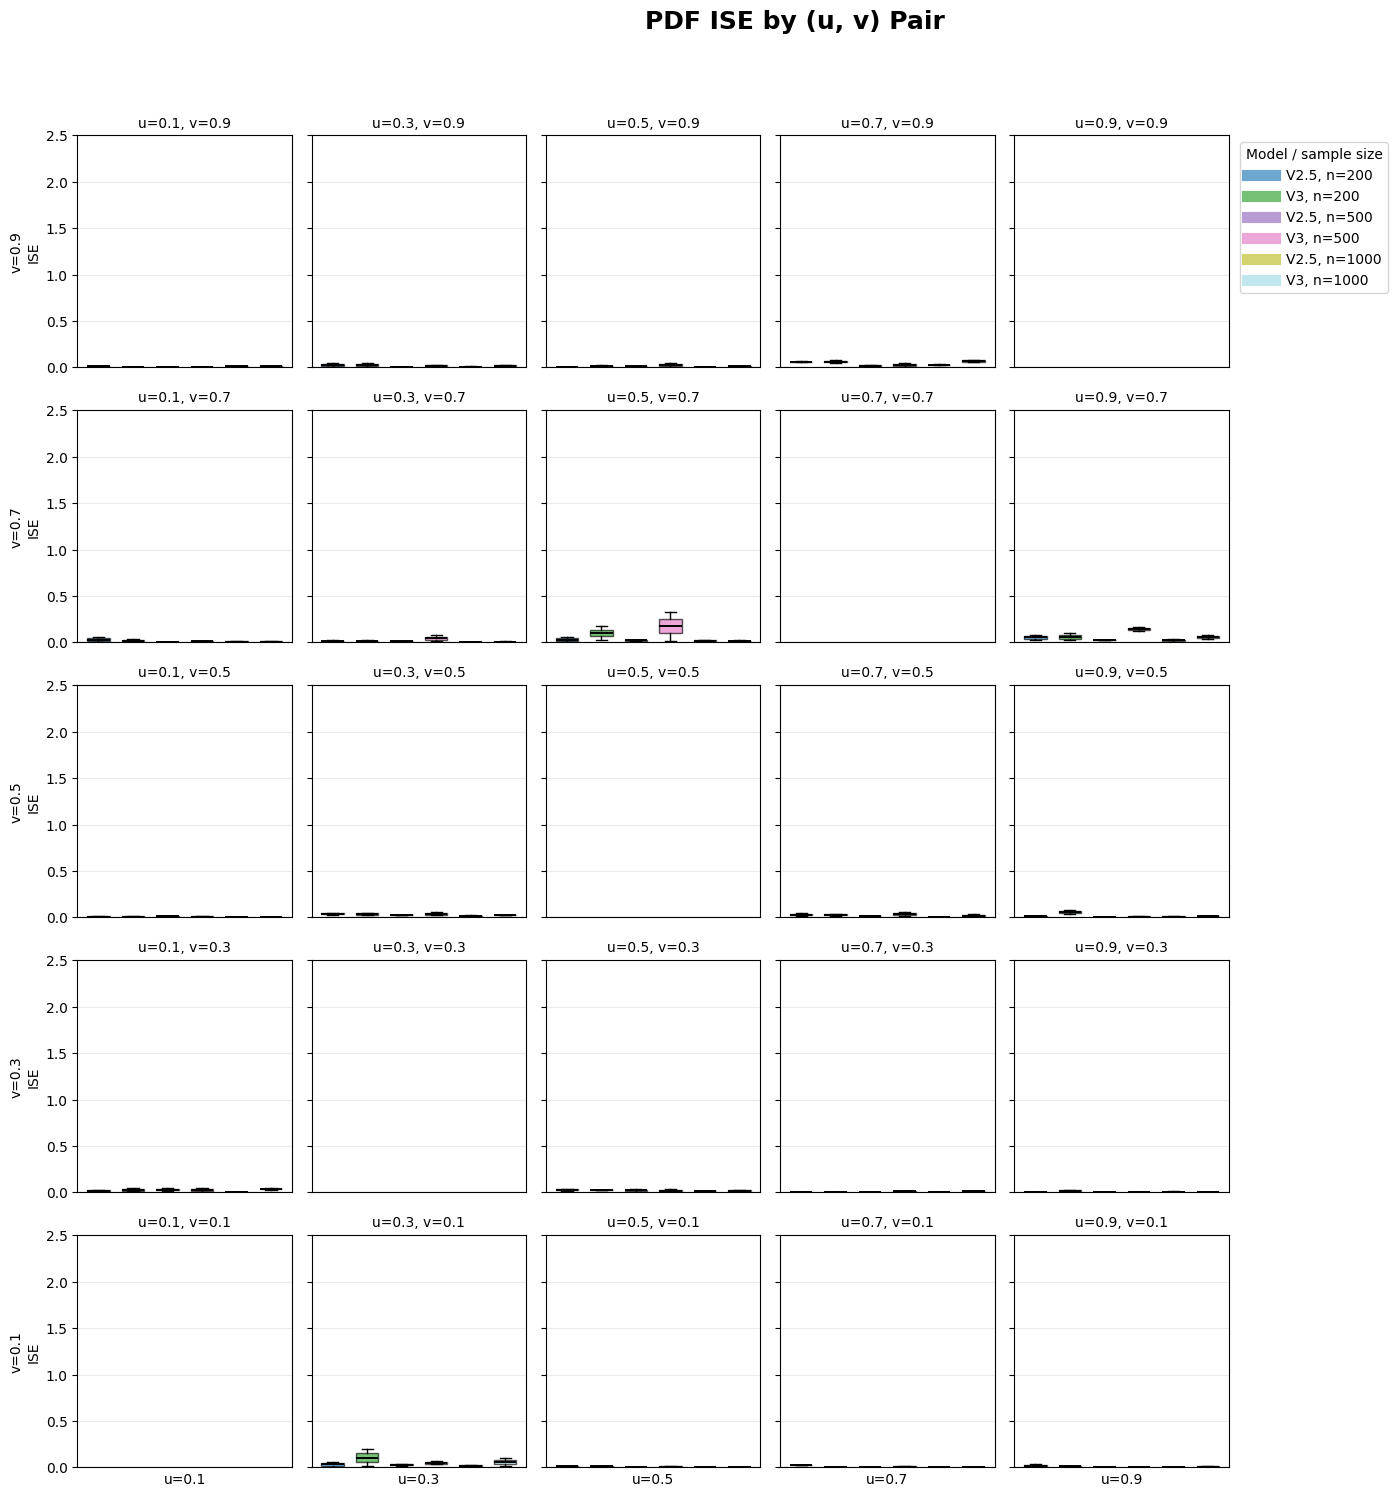

In [14]:
plot_metric_uv_boxgrid(
    rep_results,
    quantity="pdf",
    metric="ISE",
    uv_pairs=uv_pairs,
    model_order=["V2.5", "V3"],
    ylim=(0.0, 2.5),
    title="PDF ISE by (u, v) Pair",
)
plt.show()

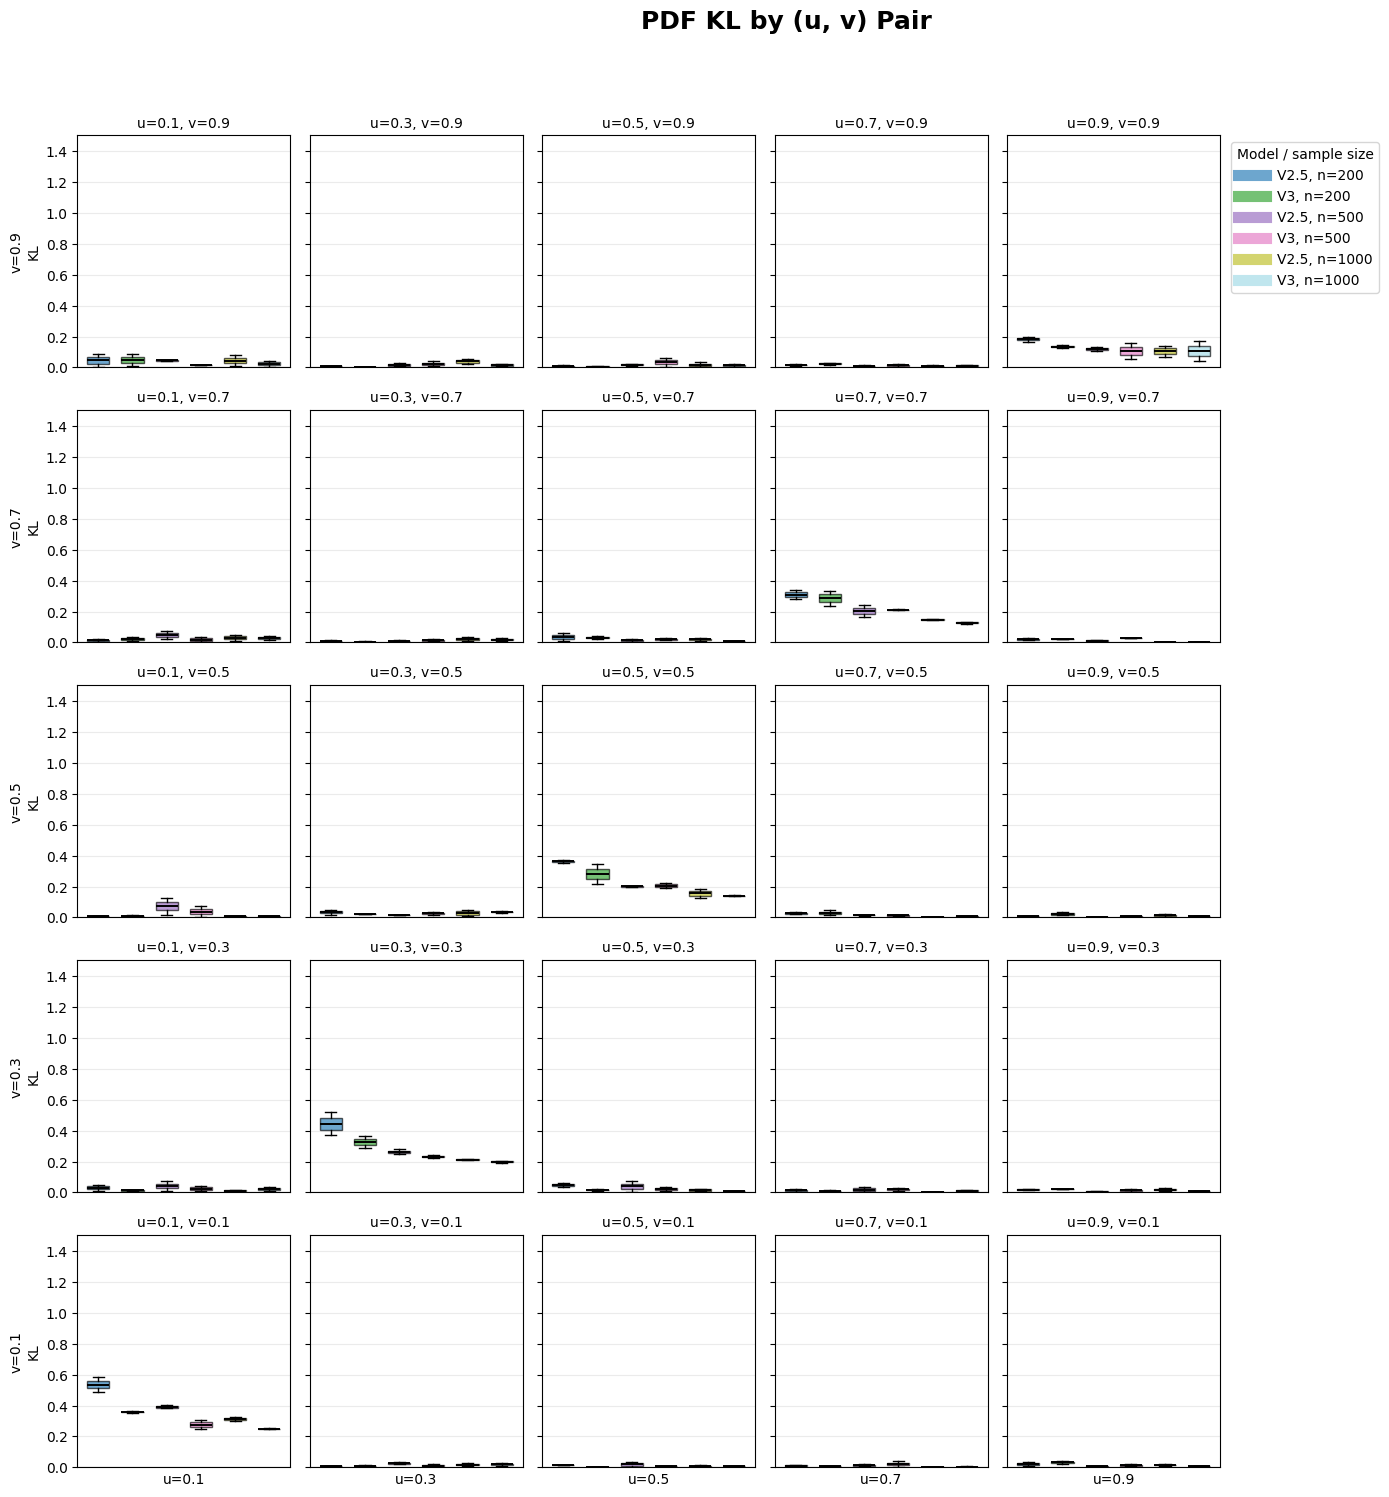

In [15]:
plot_metric_uv_boxgrid(
    rep_results,
    quantity="pdf",
    metric="KL",
    uv_pairs=uv_pairs,
    model_order=["V2.5", "V3"],
    ylim=(0.0, 1.5),
    title="PDF KL by (u, v) Pair",
)
plt.show()

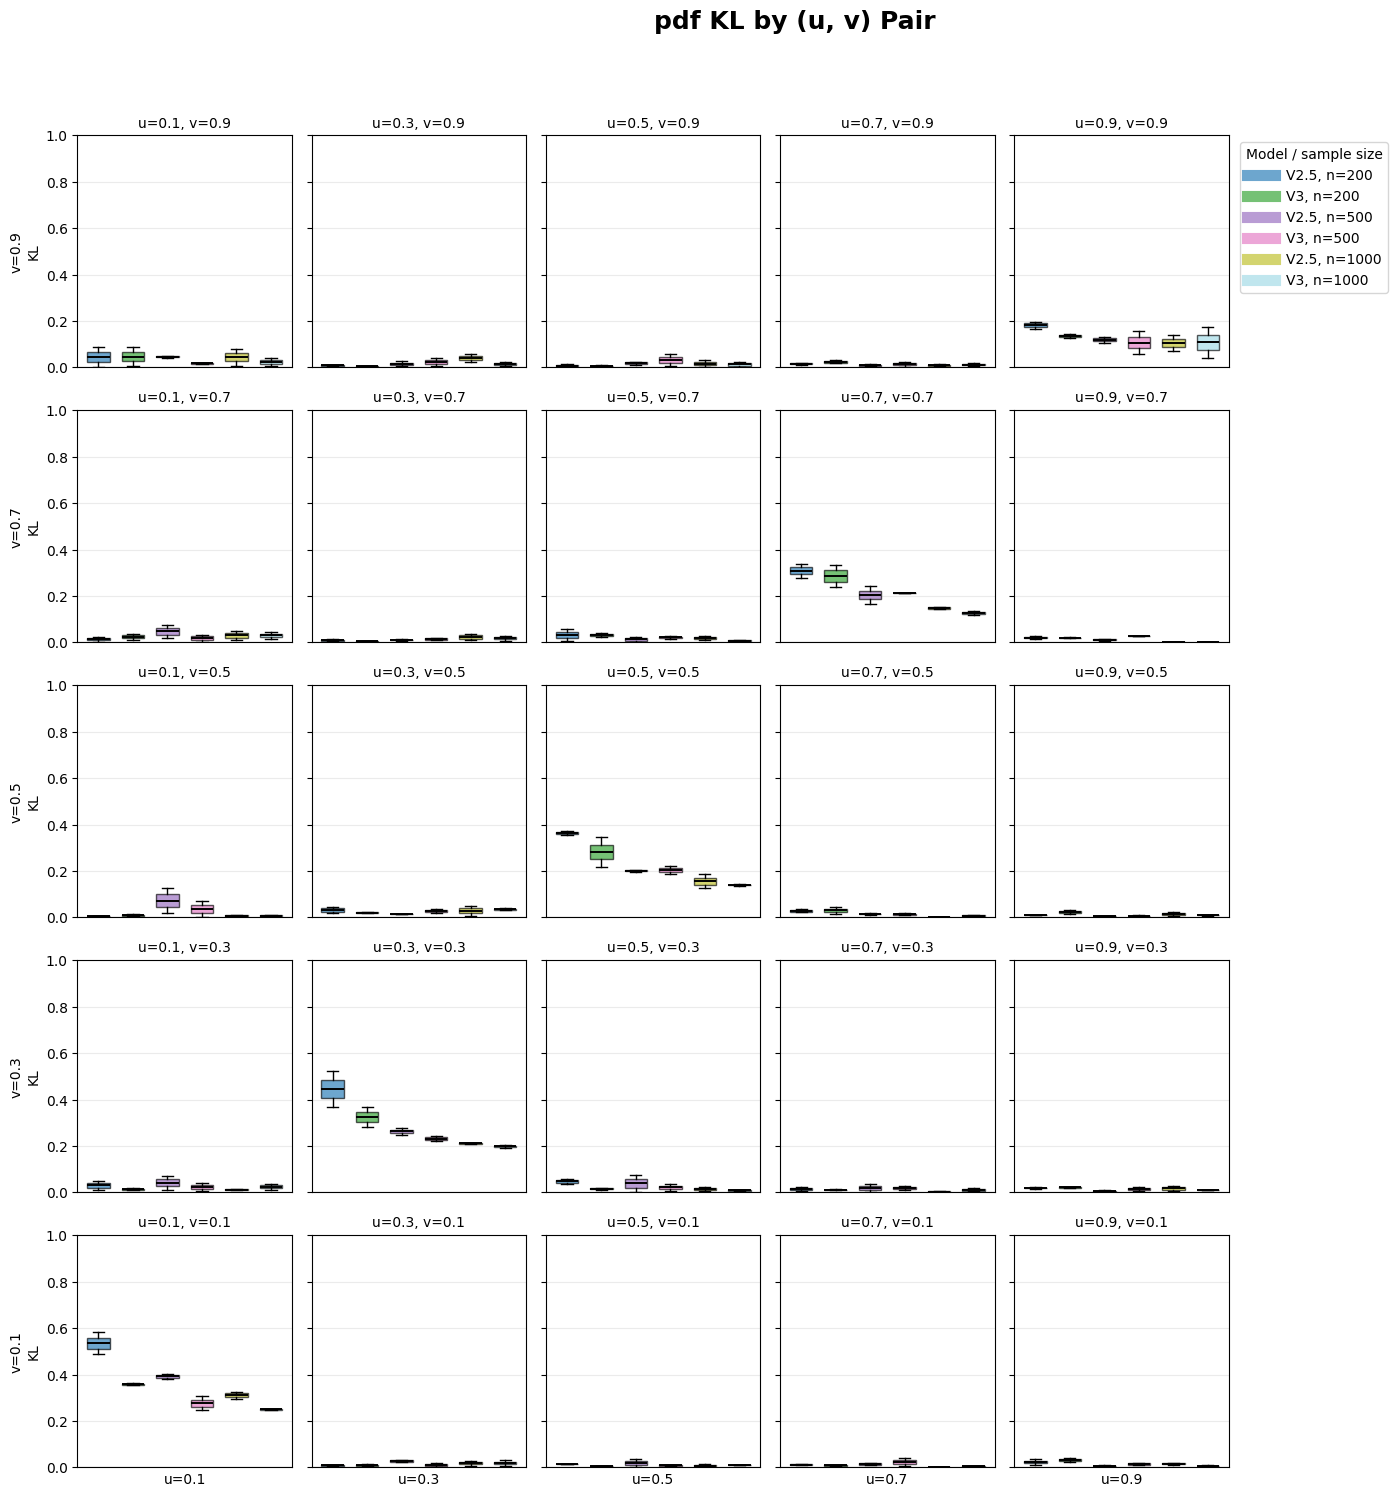

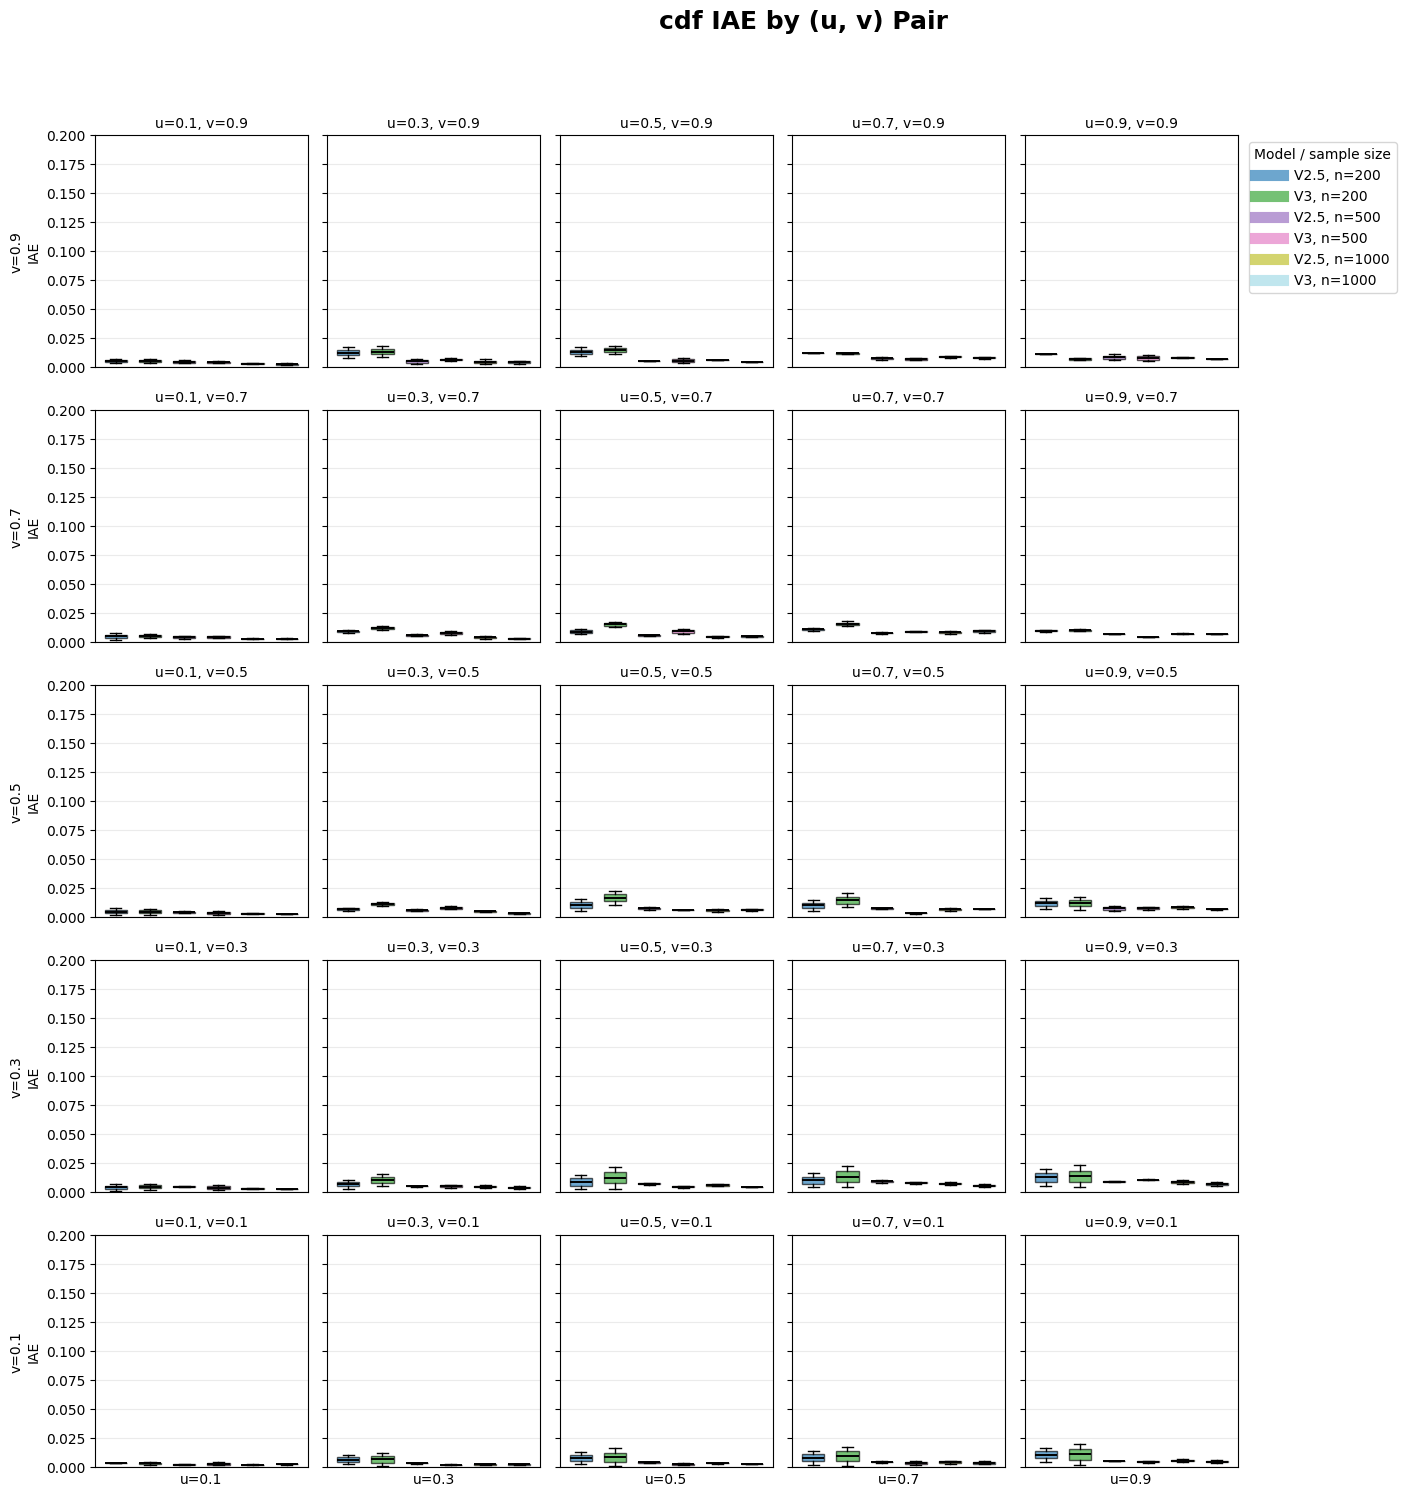

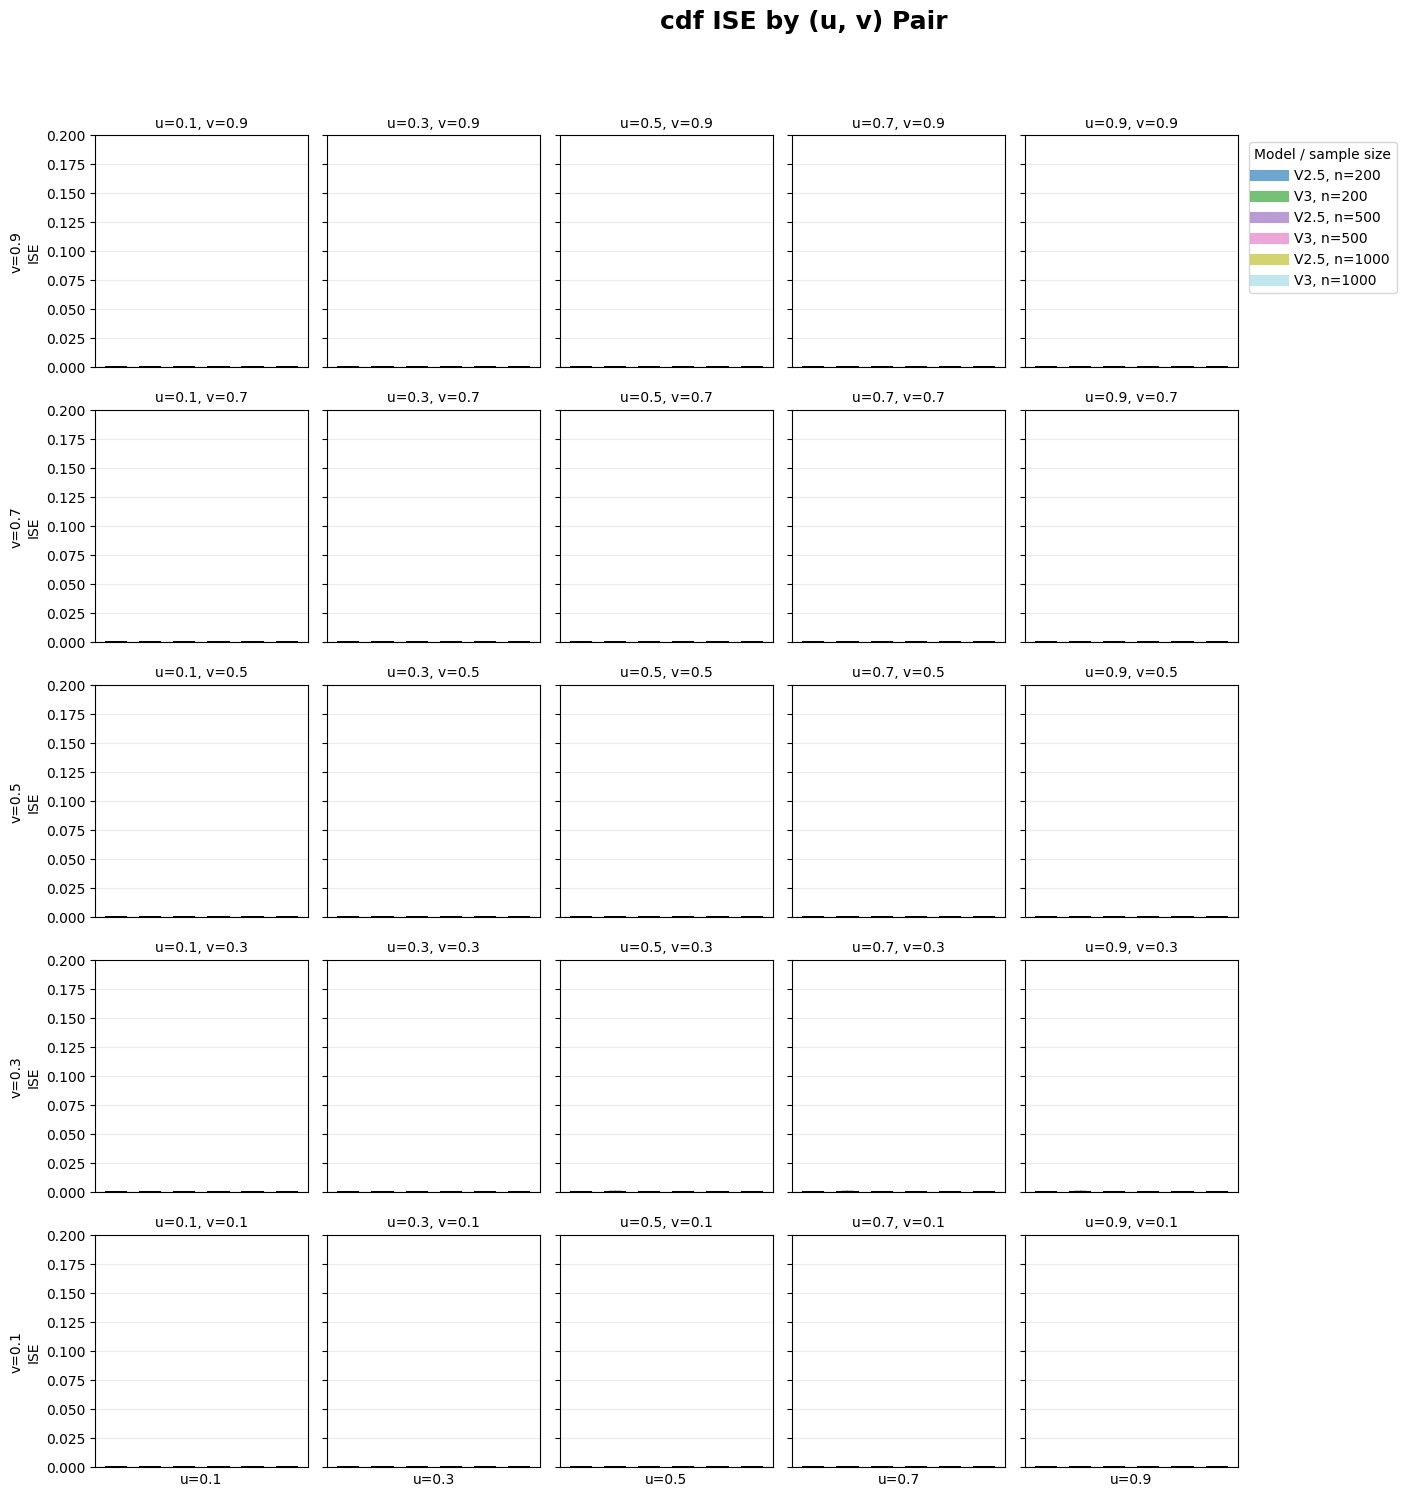

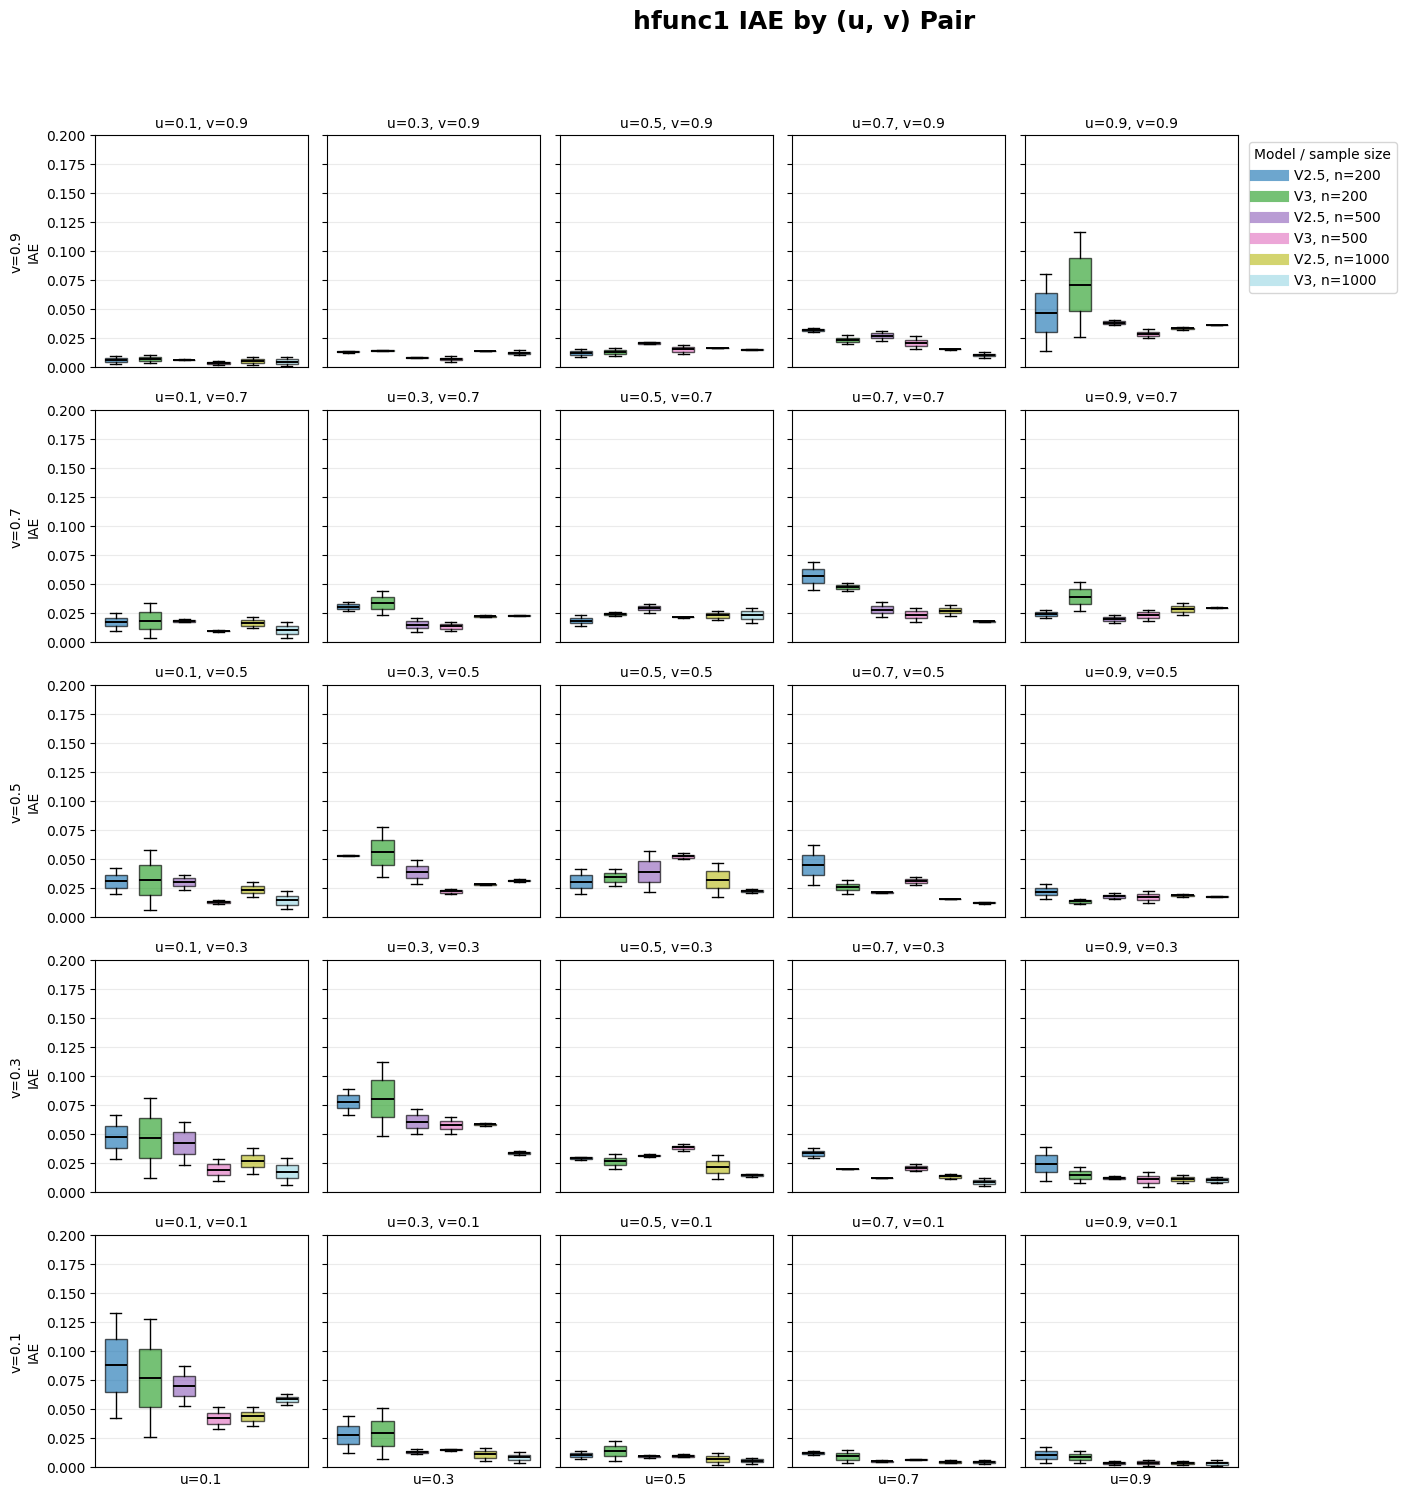

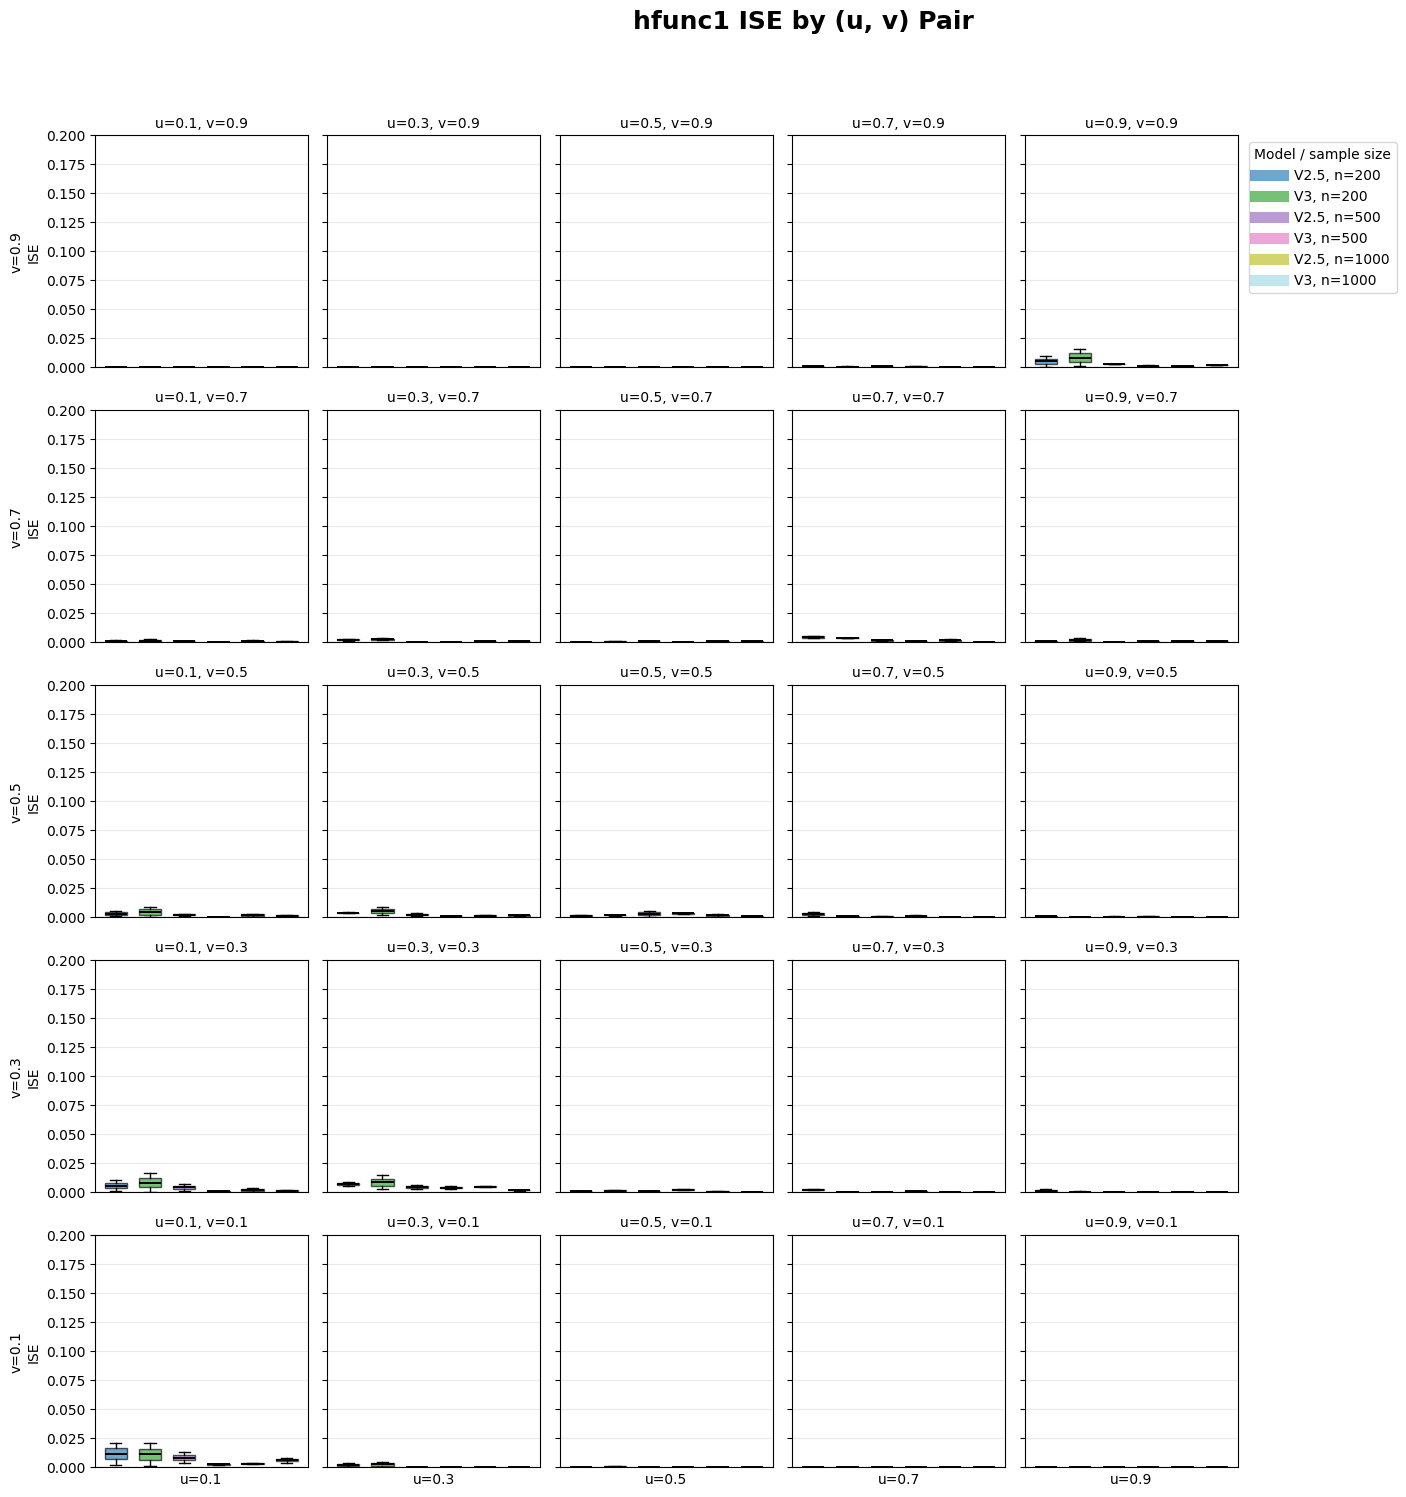

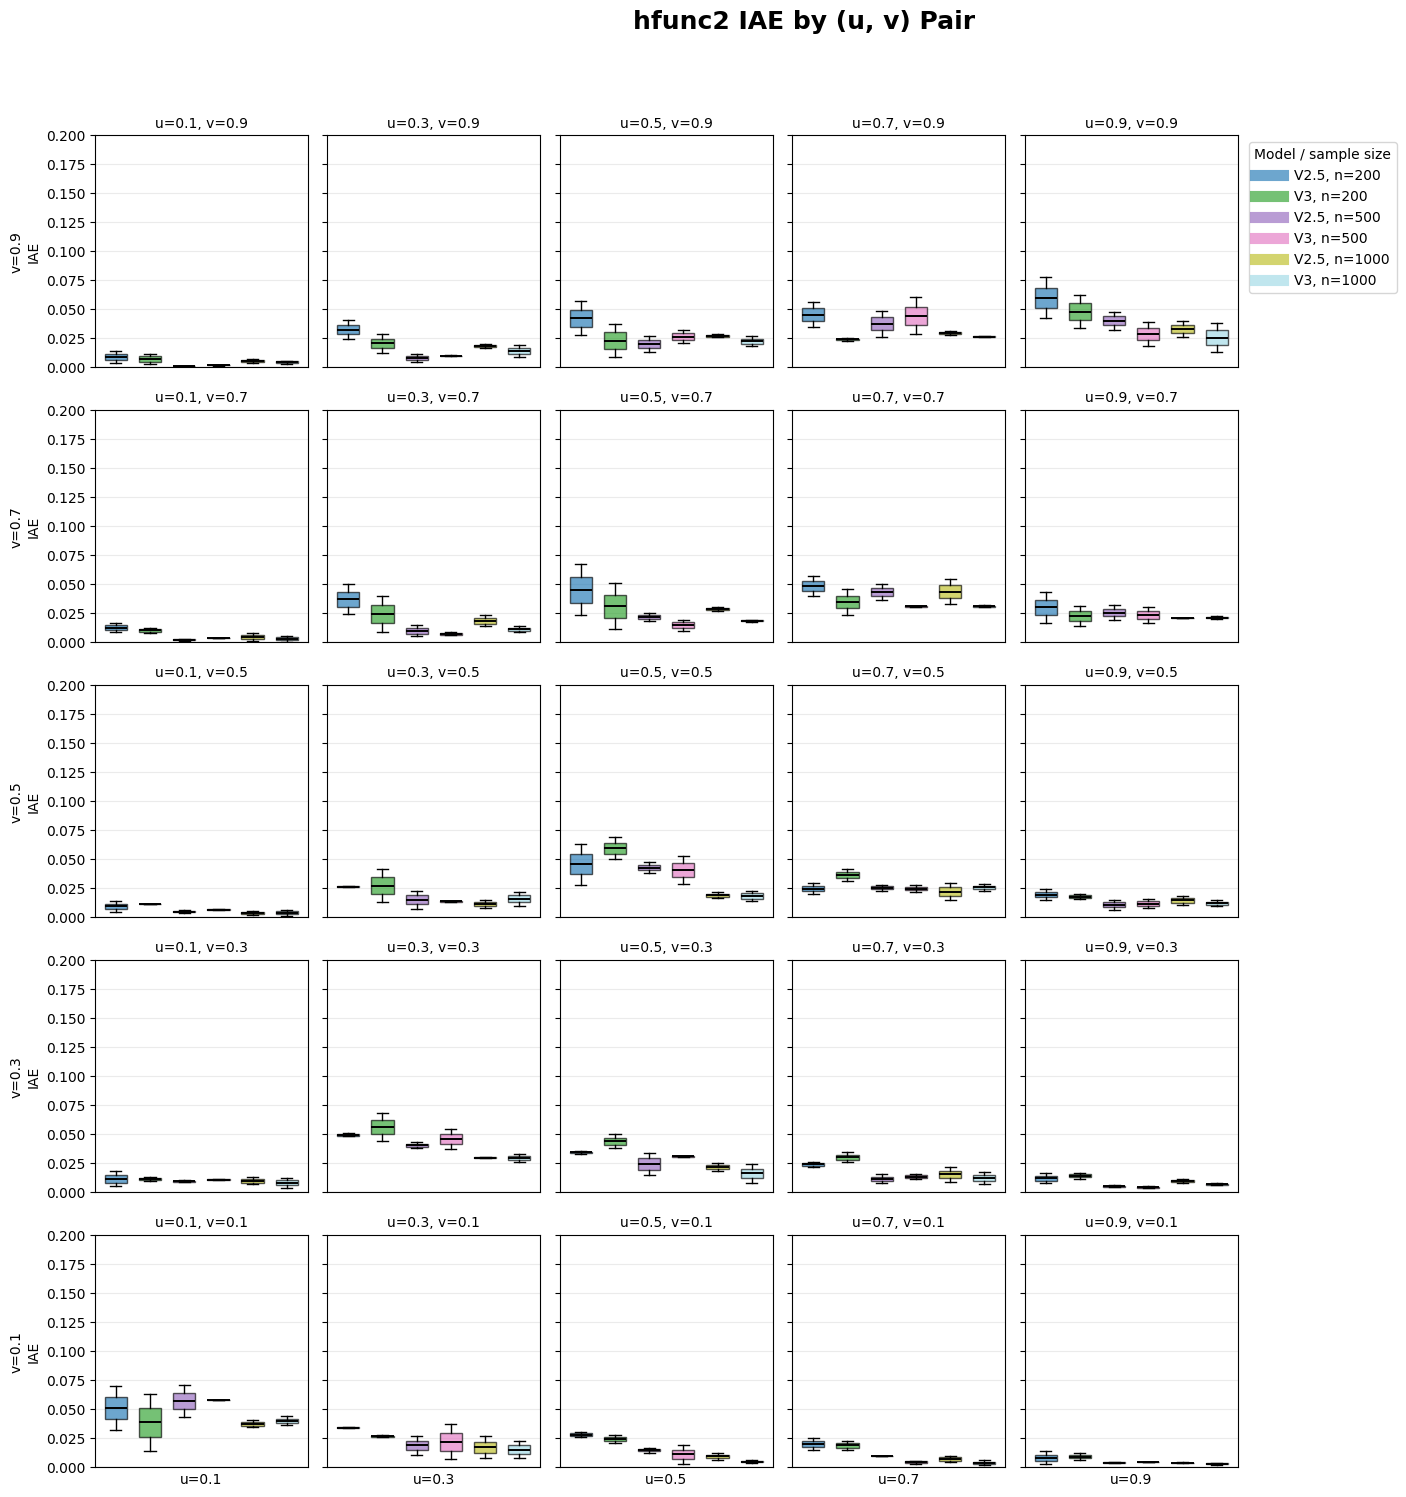

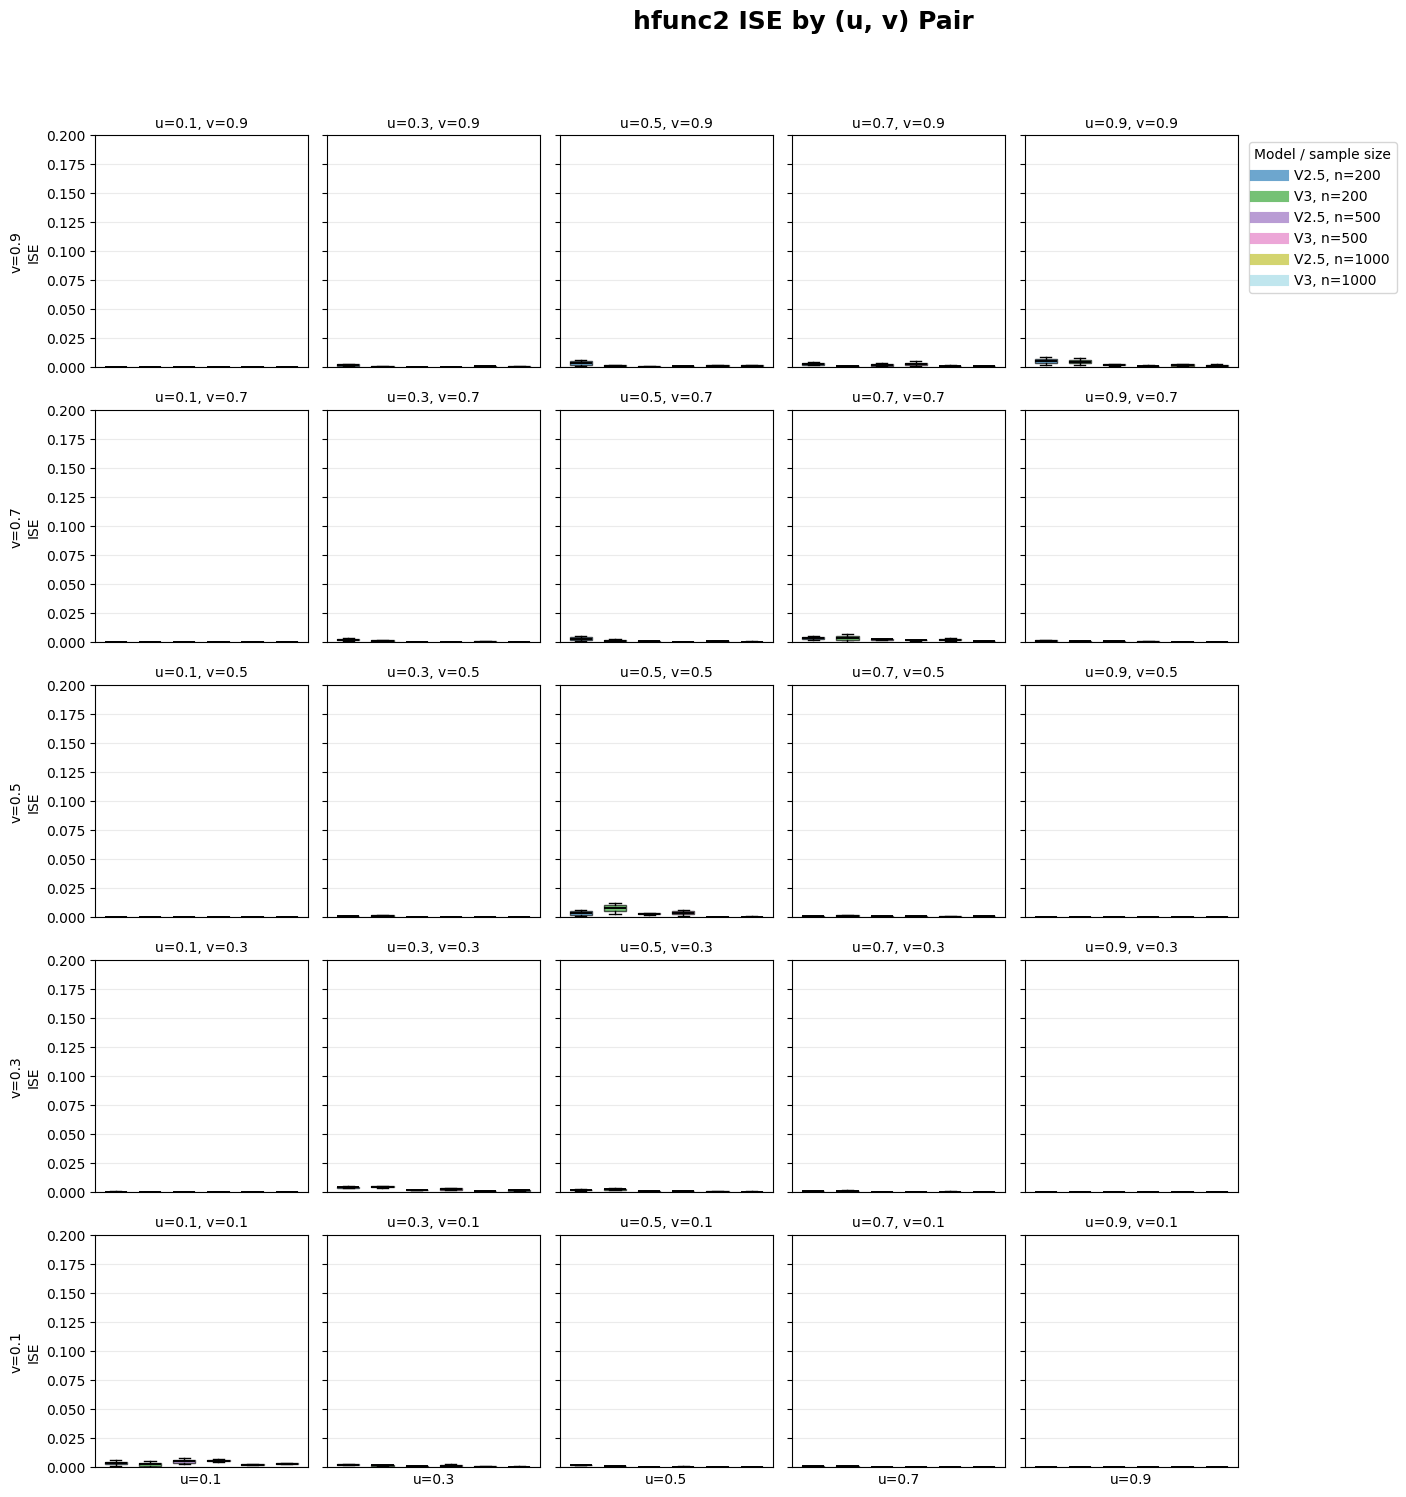

In [21]:
figs_axes = plot_all_uv_metric_boxgrids(
    rep_results,
    uv_pairs=uv_pairs,
    model_order=["V2.5", "V3"],
    metrics_by_quantity = {
        "pdf": ["KL"],
        "cdf": ["IAE", "ISE"],
        "hfunc1": ["IAE", "ISE"],
        "hfunc2": ["IAE", "ISE"],
    },
    ylim_by_metric={
        "IAE": (0.0, 0.2),
        "ISE": (0.0, 0.2),
        "KL": (0.0, 1.0),
    }
)
plt.show()

In [ ]:
figs_axes = plot_all_avg_uv_metric_boxplots(
    rep_results,
    model_order=["V2.5", "V3"],
    ylim_by_metric={
        "IAE": (0.0, 0.1),
        "ISE": (0.0, 0.1),
        "KL": (0.0, 0.1),
    },
)

plt.show()

In [ ]:
# Grouped boxplot: metrics on x-axis, model + n indicated by color
# Separate subplot per quantity

if rep_results.empty:
    print("No evaluation data. Run the Monte Carlo experiment cell first.")
else:
    metric_cols = [
        "MAE",
        "RMSE",
        "MaxAE",
        "IAE",
        "ISE",
        "MRAE",
        "KL",
    ]

    available_metrics = [c for c in metric_cols if c in rep_results.columns]

    if not available_metrics:
        print("No metric columns found in rep_results.")
    else:
        quantities = list(rep_results["quantity"].dropna().unique())

        # Nice order if available
        quantity_order = ["pdf", "cdf", "hfunc1", "hfunc2"]
        quantities = [q for q in quantity_order if q in quantities] + [
            q for q in quantities if q not in quantity_order
        ]

        n_vals = sorted(rep_results["n"].unique())
        model_vals = list(rep_results["model"].dropna().unique())

        groups = [
            (model_name, n)
            for n in n_vals
            for model_name in model_vals
        ]

        group_count = len(groups)

        fig, axes = plt.subplots(
            len(quantities),
            1,
            figsize=(16, 4.5 * len(quantities)),
            sharex=True,
        )

        if len(quantities) == 1:
            axes = [axes]

        base_positions = np.arange(len(available_metrics), dtype=float)
        group_width = 0.85
        box_width = (group_width / max(group_count, 1)) * 0.85

        if group_count == 1:
            offsets = np.array([0.0])
        else:
            offsets = np.linspace(
                -group_width / 2 + box_width / 2,
                group_width / 2 - box_width / 2,
                group_count,
            )

        colors = plt.cm.tab20(np.linspace(0, 1, max(group_count, 1)))

        for ax, quantity in zip(axes, quantities):
            quantity_df = rep_results.loc[rep_results["quantity"] == quantity]

            for i, (model_name, n) in enumerate(groups):
                mask = (
                    (quantity_df["model"] == model_name)
                    & (quantity_df["n"] == n)
                )

                grouped = [
                    quantity_df.loc[mask, metric].dropna().values
                    for metric in available_metrics
                ]

                # Skip empty groups
                if all(len(vals) == 0 for vals in grouped):
                    continue

                positions = base_positions + offsets[i]

                box = ax.boxplot(
                    grouped,
                    positions=positions,
                    widths=box_width,
                    patch_artist=True,
                    showfliers=True,
                    manage_ticks=False,
                )

                for patch in box["boxes"]:
                    patch.set_facecolor(colors[i])
                    patch.set_alpha(0.6)

                for median in box["medians"]:
                    median.set_color("black")
                    median.set_linewidth(1.5)

            ax.set_title(f"Evaluation Metrics for {quantity}")
            ax.set_ylabel("metric value")
            ax.grid(axis="y", alpha=0.3)

        axes[-1].set_xticks(base_positions)
        axes[-1].set_xticklabels(available_metrics, rotation=20, ha="right")
        axes[-1].set_xlabel("metric")

        legend_handles = [
            plt.Line2D(
                [0],
                [0],
                color=colors[i],
                lw=8,
                alpha=0.6,
                label=f"{model_name}, n={n}",
            )
            for i, (model_name, n) in enumerate(groups)
        ]

        axes[0].legend(
            handles=legend_handles,
            title="Model / sample size",
            loc="upper left",
            bbox_to_anchor=(1.01, 1.0),
        )

        fig.suptitle(
            "Evaluation Metrics by Model Version and Sample Size",
            fontsize=18,
            fontweight="bold",
            y=0.995,
        )

        fig.tight_layout(rect=[0, 0, 0.84, 0.98])
        plt.show()

In [ ]:
# Core metric boxplot: cleaner comparison

if rep_results.empty:
    print("No evaluation data. Run the Monte Carlo experiment cell first.")
else:
    core_metric_cols = [
        "IAE",
        "ISE",
        "KL",
    ]

    available_metrics = [c for c in core_metric_cols if c in rep_results.columns]

    quantities = ["pdf", "cdf", "hfunc1", "hfunc2"]
    quantities = [q for q in quantities if q in rep_results["quantity"].unique()]

    n_vals = sorted(rep_results["n"].unique())
    model_vals = list(rep_results["model"].dropna().unique())

    groups = [
        (model_name, n)
        for n in n_vals
        for model_name in model_vals
    ]

    group_count = len(groups)

    fig, axes = plt.subplots(
        len(quantities),
        1,
        figsize=(12, 4.0 * len(quantities)),
        sharex=True,
    )

    if len(quantities) == 1:
        axes = [axes]

    base_positions = np.arange(len(available_metrics), dtype=float)
    group_width = 0.85
    box_width = (group_width / max(group_count, 1)) * 0.85

    if group_count == 1:
        offsets = np.array([0.0])
    else:
        offsets = np.linspace(
            -group_width / 2 + box_width / 2,
            group_width / 2 - box_width / 2,
            group_count,
        )

    colors = plt.cm.tab20(np.linspace(0, 1, max(group_count, 1)))

    for ax, quantity in zip(axes, quantities):
        quantity_df = rep_results.loc[rep_results["quantity"] == quantity]

        # KL is only meaningful / non-NaN for pdf in your current setup.
        # For non-pdf quantities, drop KL if it is all NaN.
        metrics_for_quantity = [
            metric for metric in available_metrics
            if not quantity_df[metric].dropna().empty
        ]

        base_positions_q = np.arange(len(metrics_for_quantity), dtype=float)

        for i, (model_name, n) in enumerate(groups):
            mask = (
                (quantity_df["model"] == model_name)
                & (quantity_df["n"] == n)
            )

            grouped = [
                quantity_df.loc[mask, metric].dropna().values
                for metric in metrics_for_quantity
            ]

            if all(len(vals) == 0 for vals in grouped):
                continue

            positions = base_positions_q + offsets[i]

            box = ax.boxplot(
                grouped,
                positions=positions,
                widths=box_width,
                patch_artist=True,
                showfliers=True,
                manage_ticks=False,
            )

            for patch in box["boxes"]:
                patch.set_facecolor(colors[i])
                patch.set_alpha(0.6)

            for median in box["medians"]:
                median.set_color("black")
                median.set_linewidth(1.5)

        ax.set_title(f"{quantity}: Core Evaluation Metrics")
        ax.set_ylabel("metric value")
        ax.grid(axis="y", alpha=0.3)
        ax.set_xticks(base_positions_q)
        ax.set_xticklabels(metrics_for_quantity, rotation=20, ha="right")

    axes[-1].set_xlabel("metric")

    legend_handles = [
        plt.Line2D(
            [0],
            [0],
            color=colors[i],
            lw=8,
            alpha=0.6,
            label=f"{model_name}, n={n}",
        )
        for i, (model_name, n) in enumerate(groups)
    ]

    axes[0].legend(
        handles=legend_handles,
        title="Model / sample size",
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
    )

    fig.suptitle(
        "Core Evaluation Metrics by Model Version and Sample Size",
        fontsize=18,
        fontweight="bold",
        y=0.995,
    )

    fig.tight_layout(rect=[0, 0, 0.84, 0.98])
    plt.show()

In [ ]:
# Boxplot: PDF metrics only
# x-axis = metric
# color = model + sample size

if rep_results.empty:
    print("No evaluation data. Run the Monte Carlo experiment first.")
else:
    pdf_results = rep_results.loc[rep_results["quantity"] == "pdf"].copy()

    if pdf_results.empty:
        print("No PDF metric rows found in rep_results.")
    else:
        metric_cols = [
            "MAE",
            "RMSE",
            "MaxAE",
            "IAE",
            "ISE",
            "MRAE",
            "KL",
        ]

        available_metrics = [
            c for c in metric_cols
            if c in pdf_results.columns and not pdf_results[c].dropna().empty
        ]

        if not available_metrics:
            print("No available PDF metric columns found.")
        else:
            n_vals = sorted(pdf_results["n"].unique())
            model_vals = list(pdf_results["model"].dropna().unique())

            groups = [
                (model_name, n)
                for n in n_vals
                for model_name in model_vals
            ]

            group_count = len(groups)

            fig, ax = plt.subplots(figsize=(14, 6))

            base_positions = np.arange(len(available_metrics), dtype=float)
            group_width = 0.85
            box_width = (group_width / max(group_count, 1)) * 0.85

            if group_count == 1:
                offsets = np.array([0.0])
            else:
                offsets = np.linspace(
                    -group_width / 2 + box_width / 2,
                    group_width / 2 - box_width / 2,
                    group_count,
                )

            colors = plt.cm.tab20(np.linspace(0, 1, max(group_count, 1)))

            for i, (model_name, n) in enumerate(groups):
                mask = (
                    (pdf_results["model"] == model_name)
                    & (pdf_results["n"] == n)
                )

                grouped = [
                    pdf_results.loc[mask, metric].dropna().values
                    for metric in available_metrics
                ]

                if all(len(vals) == 0 for vals in grouped):
                    continue

                positions = base_positions + offsets[i]

                box = ax.boxplot(
                    grouped,
                    positions=positions,
                    widths=box_width,
                    patch_artist=True,
                    showfliers=True,
                    manage_ticks=False,
                )

                for patch in box["boxes"]:
                    patch.set_facecolor(colors[i])
                    patch.set_alpha(0.6)

                for median in box["medians"]:
                    median.set_color("black")
                    median.set_linewidth(1.5)

            ax.set_xticks(base_positions)
            ax.set_xticklabels(available_metrics, rotation=20, ha="right")

            ax.set_ylabel("metric value")
            ax.set_xlabel("PDF metric")
            ax.set_title("PDF Evaluation Metrics by Model Version and Sample Size")

            ax.set_ylim(0.0, 1.0)

            ax.grid(axis="y", alpha=0.3)

            legend_handles = [
                plt.Line2D(
                    [0],
                    [0],
                    color=colors[i],
                    lw=8,
                    alpha=0.6,
                    label=f"{model_name}, n={n}",
                )
                for i, (model_name, n) in enumerate(groups)
            ]

            ax.legend(
                handles=legend_handles,
                title="Model / sample size",
                loc="upper left",
                bbox_to_anchor=(1.01, 1.0),
            )

            fig.tight_layout()
            plt.show()
